# 260316 LSH 분석 시작

이번 노트북은 `pandas`로 데이터를 불러오고, 분석 대상 시작 스테이션 3개만 남기는 정제 단계까지 진행한다.

- `ST-464`
- `ST-481`
- `ST-479`

필터 기준은 `시작_대여소_ID`이다.


In [13]:
import pandas as pd
from pathlib import Path

TARGET_STATIONS = ["ST-464", "ST-481", "ST-479"]

CANDIDATE_PATHS = [
    Path("Data/정류장정보_시간대별_합친것.csv"),
    Path("../../Data/정류장정보_시간대별_합친것.csv"),
]

for candidate in CANDIDATE_PATHS:
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError("정류장정보_시간대별_합친것.csv 파일을 찾지 못했습니다.")

df = pd.read_csv(DATA_PATH)

print(f"데이터 경로: {DATA_PATH}")
print(f"전체 행 수: {len(df):,}")
print(f"컬럼 수: {df.shape[1]}")
display(df.head())
print(df.columns.tolist())


데이터 경로: ../../Data/정류장정보_시간대별_합친것.csv
전체 행 수: 1,997,933
컬럼 수: 15


,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도
0,20240101,출발시간,1735.0,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
1,20240101,도착시간,1705.0,ST-455,응암1동_032_1,ST-2779,역촌동_030_1,1.0,3.0,102.0,ST-455,서울특별시 은평구 은평로 85 CJ드림시티,NaN,37.599495,126.916985
2,20240101,도착시간,1705.0,ST-460,응암3동_017_1,ST-2425,신사1동_036_1,1.0,11.0,550.0,ST-460,서울특별시 은평구 응암동 604-5,응암오거리,37.589661,126.916946
3,20240101,도착시간,1705.0,ST-461,응암1동_032_2,ST-2425,신사1동_036_1,1.0,15.0,1582.0,ST-461,서울특별시 은평구 응암동 90-15,이마트 은평점,37.600700,126.920128
4,20240101,도착시간,1705.0,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337


['기준_날짜', '집계_기준', '기준_시간대', '시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_ID', '주소1', '주소2', '위도', '경도']


## 1차 정제

전체 데이터 중 `시작_대여소_ID`가 분석 대상 3개 스테이션에 해당하는 행만 남긴다.

즉, 대여가 시작된 지점이 아래 셋 중 하나인 데이터만 가져온다.

- `ST-464`
- `ST-481`
- `ST-479`


In [14]:
filtered_df = df[df["시작_대여소_ID"].isin(TARGET_STATIONS)].copy()

print(f"필터링 후 행 수: {len(filtered_df):,}")
print()
print("시작 스테이션별 행 수")
display(filtered_df["시작_대여소_ID"].value_counts().sort_index())


필터링 후 행 수: 140,255

시작 스테이션별 행 수


시작_대여소_ID
ST-464    31185
ST-479    65134
ST-481    43936
Name: count, dtype: int64

In [15]:
preview_columns = [
    "기준_날짜",
    "집계_기준",
    "기준_시간대",
    "시작_대여소_ID",
    "시작_대여소명",
    "종료_대여소_ID",
    "종료_대여소명",
    "전체_건수",
]

display(filtered_df[preview_columns].head())


,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수
0,20240101,출발시간,1735.0,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0
4,20240101,도착시간,1705.0,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0
10,20240101,출발시간,1710.0,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0
26,20240101,출발시간,1700.0,ST-464,역촌동_022_1,ST-463,증산동_004_1,3.0
64,20240101,도착시간,1650.0,ST-479,역촌동_068_1,ST-454,대조동_024_1,1.0


## 날짜와 시간 형식 변환

현재 `기준_날짜`와 `기준_시간대`는 숫자처럼 보이는 값으로 들어 있다.

- `기준_날짜`: `20240101` 형태
- `기준_시간대`: `1735.0` 형태

이 상태로는 시간 기준 정렬이나 시간대 분석이 불편하므로 먼저 날짜 형식으로 변환한다.

변환 방식은 다음과 같다.

- `기준_날짜`를 날짜형으로 변환
- `기준_시간대`를 `HHMM` 문자열로 정리
- 두 값을 합쳐 최종 `기준_일시` 컬럼 생성


In [16]:
filtered_df["기준_날짜"] = pd.to_datetime(
    filtered_df["기준_날짜"].astype(str),
    format="%Y%m%d"
)

filtered_df["기준_시간대_str"] = (
    filtered_df["기준_시간대"]
    .fillna(0)
    .astype(float)
    .astype(int)
    .astype(str)
    .str.zfill(4)
)

filtered_df["기준_일시"] = pd.to_datetime(
    filtered_df["기준_날짜"].dt.strftime("%Y-%m-%d") + " " + filtered_df["기준_시간대_str"],
    format="%Y-%m-%d %H%M"
)

filtered_df["기준_연도"] = filtered_df["기준_일시"].dt.year
filtered_df["기준_월"] = filtered_df["기준_일시"].dt.month
filtered_df["기준_일"] = filtered_df["기준_일시"].dt.day
filtered_df["기준_시"] = filtered_df["기준_일시"].dt.hour
filtered_df["기준_분"] = filtered_df["기준_일시"].dt.minute

print(filtered_df[["기준_날짜", "기준_시간대", "기준_시간대_str", "기준_일시"]].dtypes)
display(
    filtered_df[
        ["기준_날짜", "기준_시간대", "기준_시간대_str", "기준_일시", "기준_시", "기준_분"]
    ].head()
)


기준_날짜         datetime64[us]
기준_시간대               float64
기준_시간대_str               str
기준_일시         datetime64[us]
dtype: object


,기준_날짜,기준_시간대,기준_시간대_str,기준_일시,기준_시,기준_분
0,2024-01-01,1735.0,1735,2024-01-01 17:35:00,17,35
4,2024-01-01,1705.0,1705,2024-01-01 17:05:00,17,5
10,2024-01-01,1710.0,1710,2024-01-01 17:10:00,17,10
26,2024-01-01,1700.0,1700,2024-01-01 17:00:00,17,0
64,2024-01-01,1650.0,1650,2024-01-01 16:50:00,16,50


## 집계 기준을 출발시간으로 통일

이 데이터는 `집계_기준`이 `출발시간`인 행과 `도착시간`인 행이 섞여 있다.
분석 기준을 하나로 맞추려면 `도착시간` 행도 실제 출발 시각으로 환산해야 한다.

여기서는 `전체_이용_분`을 이용해 아래처럼 처리한다.

- 원래 `출발시간`인 행은 그대로 사용
- 원래 `도착시간`인 행은 `기준_일시 - 전체_이용_분`으로 출발 시각 계산
- 계산이 끝나면 분석용 `집계_기준`을 전부 `출발시간`으로 통일

예를 들어 `2024-01-02 00:10` 도착, `전체_이용_분 = 30`이면 실제 출발 시각은 `2024-01-01 23:40`이다.
즉 자정을 넘겨 거슬러 올라가는 경우 날짜는 하루 뒤가 아니라 하루 전으로 바뀐다.


In [17]:
filtered_df["원본_집계_기준"] = filtered_df["집계_기준"]
filtered_df["원본_기준_일시"] = filtered_df["기준_일시"]

filtered_df["전체_이용_분"] = pd.to_numeric(filtered_df["전체_이용_분"], errors="coerce").fillna(0)

arrival_mask = filtered_df["원본_집계_기준"] == "도착시간"
filtered_df["출발_기준_일시"] = filtered_df["원본_기준_일시"]
filtered_df.loc[arrival_mask, "출발_기준_일시"] = (
    filtered_df.loc[arrival_mask, "원본_기준_일시"]
    - pd.to_timedelta(filtered_df.loc[arrival_mask, "전체_이용_분"], unit="m")
)

filtered_df["집계_기준"] = "출발시간"
filtered_df["기준_일시"] = filtered_df["출발_기준_일시"]
filtered_df["기준_날짜"] = filtered_df["기준_일시"].dt.normalize()
filtered_df["기준_시간대_str"] = filtered_df["기준_일시"].dt.strftime("%H%M")
filtered_df["기준_시간대"] = filtered_df["기준_시간대_str"].astype(int)
filtered_df["기준_연도"] = filtered_df["기준_일시"].dt.year
filtered_df["기준_월"] = filtered_df["기준_일시"].dt.month
filtered_df["기준_일"] = filtered_df["기준_일시"].dt.day
filtered_df["기준_시"] = filtered_df["기준_일시"].dt.hour
filtered_df["기준_분"] = filtered_df["기준_일시"].dt.minute

print("원본 집계 기준 분포")
display(filtered_df["원본_집계_기준"].value_counts())
print("\n변환 후 집계 기준 분포")
display(filtered_df["집계_기준"].value_counts())

preview_columns = [
    "원본_집계_기준",
    "원본_기준_일시",
    "전체_이용_분",
    "집계_기준",
    "기준_일시",
    "기준_날짜",
    "기준_시간대",
]

display(filtered_df[preview_columns].head(10))


원본 집계 기준 분포


원본_집계_기준
출발시간    70144
도착시간    70111
Name: count, dtype: int64


변환 후 집계 기준 분포


집계_기준
출발시간    140255
Name: count, dtype: int64

,원본_집계_기준,원본_기준_일시,전체_이용_분,집계_기준,기준_일시,기준_날짜,기준_시간대
0,출발시간,2024-01-01 17:35:00,151.0,출발시간,2024-01-01 17:35:00,2024-01-01,1735
4,도착시간,2024-01-01 17:05:00,22.0,출발시간,2024-01-01 16:43:00,2024-01-01,1643
10,출발시간,2024-01-01 17:10:00,16.0,출발시간,2024-01-01 17:10:00,2024-01-01,1710
26,출발시간,2024-01-01 17:00:00,65.0,출발시간,2024-01-01 17:00:00,2024-01-01,1700
64,도착시간,2024-01-01 16:50:00,7.0,출발시간,2024-01-01 16:43:00,2024-01-01,1643
76,도착시간,2024-01-01 16:55:00,17.0,출발시간,2024-01-01 16:38:00,2024-01-01,1638
115,출발시간,2024-01-01 17:35:00,17.0,출발시간,2024-01-01 17:35:00,2024-01-01,1735
128,출발시간,2024-01-01 16:40:00,7.0,출발시간,2024-01-01 16:40:00,2024-01-01,1640
149,출발시간,2024-01-01 16:50:00,35.0,출발시간,2024-01-01 16:50:00,2024-01-01,1650
157,출발시간,2024-01-01 16:45:00,22.0,출발시간,2024-01-01 16:45:00,2024-01-01,1645


## 분석용 데이터프레임 생성

중간 변환 확인용으로만 썼던 컬럼은 제외하고, 실제 분석에 사용할 새 데이터프레임을 만든다.

우선 아래 컬럼들을 제거한다.

- `원본_기준_일시`
- `기준_월`
- `기준_일`
- `기준_시`
- `기준_분`
- `기준_날짜`
- `집계_기준`
- `기준_시간대`


In [18]:
drop_columns = [
    "원본_기준_일시",
    "기준_월",
    "기준_일",
    "기준_시",
    "기준_분",
    "기준_날짜",
    "집계_기준",
    "기준_시간대",
]

analysis_df = filtered_df.drop(columns=drop_columns, errors="ignore").copy()

print(f"analysis_df 행 수: {len(analysis_df):,}")
print(f"analysis_df 컬럼 수: {analysis_df.shape[1]}")
print(analysis_df.columns.tolist())
display(analysis_df.head())


analysis_df 행 수: 140,255
analysis_df 컬럼 수: 17
['시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_ID', '주소1', '주소2', '위도', '경도', '기준_시간대_str', '기준_일시', '기준_연도', '원본_집계_기준', '출발_기준_일시']


,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도,기준_시간대_str,기준_일시,기준_연도,원본_집계_기준,출발_기준_일시
0,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,1735,2024-01-01 17:35:00,2024,출발시간,2024-01-01 17:35:00
4,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,1643,2024-01-01 16:43:00,2024,도착시간,2024-01-01 16:43:00
10,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,16.0,169.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,1710,2024-01-01 17:10:00,2024,출발시간,2024-01-01 17:10:00
26,ST-464,역촌동_022_1,ST-463,증산동_004_1,3.0,65.0,8110.0,ST-464,서울특별시 은평구 역촌동 15-40,평생학습관 앞,37.607849,126.921326,1700,2024-01-01 17:00:00,2024,출발시간,2024-01-01 17:00:00
64,ST-479,역촌동_068_1,ST-454,대조동_024_1,1.0,7.0,1390.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,1643,2024-01-01 16:43:00,2024,도착시간,2024-01-01 16:43:00


## 0값 행 제거

`analysis_df`에서 `전체_이용_거리`와 `전체_이용_분`이 모두 0인 행은 실제 이동 정보가 없는 결측성 데이터로 보고 제거한다.


In [19]:
analysis_df["전체_이용_거리"] = pd.to_numeric(analysis_df["전체_이용_거리"], errors="coerce").fillna(0)
analysis_df["전체_이용_분"] = pd.to_numeric(analysis_df["전체_이용_분"], errors="coerce").fillna(0)

before_count = len(analysis_df)
zero_mask = (analysis_df["전체_이용_거리"] == 0) & (analysis_df["전체_이용_분"] == 0)
zero_rows_count = zero_mask.sum()

analysis_df = analysis_df.loc[~zero_mask].copy()
after_count = len(analysis_df)

print(f"제거 전 행 수: {before_count:,}")
print(f"제거된 행 수: {zero_rows_count:,}")
print(f"제거 후 행 수: {after_count:,}")
display(analysis_df.head())


제거 전 행 수: 140,255
제거된 행 수: 2,469
제거 후 행 수: 137,786


,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도,기준_시간대_str,기준_일시,기준_연도,원본_집계_기준,출발_기준_일시
0,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,1735,2024-01-01 17:35:00,2024,출발시간,2024-01-01 17:35:00
4,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,1643,2024-01-01 16:43:00,2024,도착시간,2024-01-01 16:43:00
10,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,16.0,169.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,1710,2024-01-01 17:10:00,2024,출발시간,2024-01-01 17:10:00
26,ST-464,역촌동_022_1,ST-463,증산동_004_1,3.0,65.0,8110.0,ST-464,서울특별시 은평구 역촌동 15-40,평생학습관 앞,37.607849,126.921326,1700,2024-01-01 17:00:00,2024,출발시간,2024-01-01 17:00:00
64,ST-479,역촌동_068_1,ST-454,대조동_024_1,1.0,7.0,1390.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,1643,2024-01-01 16:43:00,2024,도착시간,2024-01-01 16:43:00


## 주말 및 공휴일 컬럼 생성

일자별 패턴을 보기 위해 `주말_공휴일_여부` 컬럼을 만든다.

- 주말 또는 공휴일이면 `1`
- 그 외 평일이면 `0`

기준은 `기준_일시`의 날짜 부분이며, 공휴일은 2024년 대한민국 공휴일 기준으로 넣는다.


In [20]:
holiday_dates_2024 = pd.to_datetime([
    "2024-01-01",
    "2024-02-09", "2024-02-10", "2024-02-11", "2024-02-12",
    "2024-03-01",
    "2024-04-10",
    "2024-05-05", "2024-05-06", "2024-05-15",
    "2024-06-06",
    "2024-08-15",
    "2024-09-16", "2024-09-17", "2024-09-18",
    "2024-10-03", "2024-10-09",
    "2024-12-25",
])

analysis_df["기준_날짜_only"] = analysis_df["기준_일시"].dt.normalize()
analysis_df["주말_여부"] = (analysis_df["기준_일시"].dt.weekday >= 5).astype(int)
analysis_df["공휴일_여부"] = analysis_df["기준_날짜_only"].isin(holiday_dates_2024).astype(int)
analysis_df["주말_공휴일_여부"] = ((analysis_df["주말_여부"] == 1) | (analysis_df["공휴일_여부"] == 1)).astype(int)

display(analysis_df[["기준_일시", "기준_날짜_only", "주말_여부", "공휴일_여부", "주말_공휴일_여부"]].head(10))
print(analysis_df["주말_공휴일_여부"].value_counts().sort_index())


,기준_일시,기준_날짜_only,주말_여부,공휴일_여부,주말_공휴일_여부
0,2024-01-01 17:35:00,2024-01-01,0,1,1
4,2024-01-01 16:43:00,2024-01-01,0,1,1
10,2024-01-01 17:10:00,2024-01-01,0,1,1
26,2024-01-01 17:00:00,2024-01-01,0,1,1
64,2024-01-01 16:43:00,2024-01-01,0,1,1
76,2024-01-01 16:38:00,2024-01-01,0,1,1
115,2024-01-01 17:35:00,2024-01-01,0,1,1
128,2024-01-01 16:40:00,2024-01-01,0,1,1
149,2024-01-01 16:50:00,2024-01-01,0,1,1
157,2024-01-01 16:45:00,2024-01-01,0,1,1


주말_공휴일_여부
0    97187
1    40599
Name: count, dtype: int64


## 현재 사용하는 데이터프레임 확인

현재 분석 과정에서 사용하는 데이터프레임들의 크기, 컬럼, 앞부분 데이터를 한 번에 확인한다.


In [21]:
dataframes_to_view = {
    "df": df,
    "filtered_df": filtered_df,
    "analysis_df": analysis_df,
}

for name, frame in dataframes_to_view.items():
    print(f"[{name}]")
    print(f"shape: {frame.shape}")
    print("columns:")
    print(frame.columns.tolist())
    display(frame.head())
    print()


[df]
shape: (1997933, 15)
columns:
['기준_날짜', '집계_기준', '기준_시간대', '시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_ID', '주소1', '주소2', '위도', '경도']


,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도
0,20240101,출발시간,1735.0,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
1,20240101,도착시간,1705.0,ST-455,응암1동_032_1,ST-2779,역촌동_030_1,1.0,3.0,102.0,ST-455,서울특별시 은평구 은평로 85 CJ드림시티,NaN,37.599495,126.916985
2,20240101,도착시간,1705.0,ST-460,응암3동_017_1,ST-2425,신사1동_036_1,1.0,11.0,550.0,ST-460,서울특별시 은평구 응암동 604-5,응암오거리,37.589661,126.916946
3,20240101,도착시간,1705.0,ST-461,응암1동_032_2,ST-2425,신사1동_036_1,1.0,15.0,1582.0,ST-461,서울특별시 은평구 응암동 90-15,이마트 은평점,37.600700,126.920128
4,20240101,도착시간,1705.0,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337



[filtered_df]
shape: (140255, 25)
columns:
['기준_날짜', '집계_기준', '기준_시간대', '시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_ID', '주소1', '주소2', '위도', '경도', '기준_시간대_str', '기준_일시', '기준_연도', '기준_월', '기준_일', '기준_시', '기준_분', '원본_집계_기준', '원본_기준_일시', '출발_기준_일시']


,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,...,기준_시간대_str,기준_일시,기준_연도,기준_월,기준_일,기준_시,기준_분,원본_집계_기준,원본_기준_일시,출발_기준_일시
0,2024-01-01,출발시간,1735,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,...,1735,2024-01-01 17:35:00,2024,1,1,17,35,출발시간,2024-01-01 17:35:00,2024-01-01 17:35:00
4,2024-01-01,출발시간,1643,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,...,1643,2024-01-01 16:43:00,2024,1,1,16,43,도착시간,2024-01-01 17:05:00,2024-01-01 16:43:00
10,2024-01-01,출발시간,1710,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,16.0,169.0,...,1710,2024-01-01 17:10:00,2024,1,1,17,10,출발시간,2024-01-01 17:10:00,2024-01-01 17:10:00
26,2024-01-01,출발시간,1700,ST-464,역촌동_022_1,ST-463,증산동_004_1,3.0,65.0,8110.0,...,1700,2024-01-01 17:00:00,2024,1,1,17,0,출발시간,2024-01-01 17:00:00,2024-01-01 17:00:00
64,2024-01-01,출발시간,1643,ST-479,역촌동_068_1,ST-454,대조동_024_1,1.0,7.0,1390.0,...,1643,2024-01-01 16:43:00,2024,1,1,16,43,도착시간,2024-01-01 16:50:00,2024-01-01 16:43:00



[analysis_df]
shape: (137786, 21)
columns:
['시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_ID', '주소1', '주소2', '위도', '경도', '기준_시간대_str', '기준_일시', '기준_연도', '원본_집계_기준', '출발_기준_일시', '기준_날짜_only', '주말_여부', '공휴일_여부', '주말_공휴일_여부']


,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,...,경도,기준_시간대_str,기준_일시,기준_연도,원본_집계_기준,출발_기준_일시,기준_날짜_only,주말_여부,공휴일_여부,주말_공휴일_여부
0,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,...,126.915337,1735,2024-01-01 17:35:00,2024,출발시간,2024-01-01 17:35:00,2024-01-01,0,1,1
4,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,...,126.915337,1643,2024-01-01 16:43:00,2024,도착시간,2024-01-01 16:43:00,2024-01-01,0,1,1
10,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,16.0,169.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,...,126.915337,1710,2024-01-01 17:10:00,2024,출발시간,2024-01-01 17:10:00,2024-01-01,0,1,1
26,ST-464,역촌동_022_1,ST-463,증산동_004_1,3.0,65.0,8110.0,ST-464,서울특별시 은평구 역촌동 15-40,평생학습관 앞,...,126.921326,1700,2024-01-01 17:00:00,2024,출발시간,2024-01-01 17:00:00,2024-01-01,0,1,1
64,ST-479,역촌동_068_1,ST-454,대조동_024_1,1.0,7.0,1390.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,...,126.915337,1643,2024-01-01 16:43:00,2024,도착시간,2024-01-01 16:43:00,2024-01-01,0,1,1


## 출발 시각 계산 검증

`도착시간` 기준 행은 `원본_기준_일시 - 전체_이용_분`으로 출발 시각을 계산했다.
아래 셀에서는 실제로 그 차이가 `전체_이용_분`과 일치하는지 확인한다.


In [22]:
check_columns = [
    "원본_집계_기준",
    "원본_기준_일시",
    "전체_이용_분",
    "출발_기준_일시",
    "기준_일시",
]

print("전체 데이터 일부 확인")
display(filtered_df[check_columns].head(10))

arrival_check_df = filtered_df[filtered_df["원본_집계_기준"] == "도착시간"].copy()
arrival_check_df["차이_분"] = (
    (arrival_check_df["원본_기준_일시"] - arrival_check_df["출발_기준_일시"])
    .dt.total_seconds() / 60
)

print("도착시간 행만 따로 확인")
display(arrival_check_df[check_columns + ["차이_분"]].head(10))


전체 데이터 일부 확인


,원본_집계_기준,원본_기준_일시,전체_이용_분,출발_기준_일시,기준_일시
0,출발시간,2024-01-01 17:35:00,151.0,2024-01-01 17:35:00,2024-01-01 17:35:00
4,도착시간,2024-01-01 17:05:00,22.0,2024-01-01 16:43:00,2024-01-01 16:43:00
10,출발시간,2024-01-01 17:10:00,16.0,2024-01-01 17:10:00,2024-01-01 17:10:00
26,출발시간,2024-01-01 17:00:00,65.0,2024-01-01 17:00:00,2024-01-01 17:00:00
64,도착시간,2024-01-01 16:50:00,7.0,2024-01-01 16:43:00,2024-01-01 16:43:00
76,도착시간,2024-01-01 16:55:00,17.0,2024-01-01 16:38:00,2024-01-01 16:38:00
115,출발시간,2024-01-01 17:35:00,17.0,2024-01-01 17:35:00,2024-01-01 17:35:00
128,출발시간,2024-01-01 16:40:00,7.0,2024-01-01 16:40:00,2024-01-01 16:40:00
149,출발시간,2024-01-01 16:50:00,35.0,2024-01-01 16:50:00,2024-01-01 16:50:00
157,출발시간,2024-01-01 16:45:00,22.0,2024-01-01 16:45:00,2024-01-01 16:45:00


도착시간 행만 따로 확인


,원본_집계_기준,원본_기준_일시,전체_이용_분,출발_기준_일시,기준_일시,차이_분
4,도착시간,2024-01-01 17:05:00,22.0,2024-01-01 16:43:00,2024-01-01 16:43:00,22.0
64,도착시간,2024-01-01 16:50:00,7.0,2024-01-01 16:43:00,2024-01-01 16:43:00,7.0
76,도착시간,2024-01-01 16:55:00,17.0,2024-01-01 16:38:00,2024-01-01 16:38:00,17.0
166,도착시간,2024-01-01 17:30:00,141.0,2024-01-01 15:09:00,2024-01-01 15:09:00,141.0
212,도착시간,2024-01-01 17:55:00,103.0,2024-01-01 16:12:00,2024-01-01 16:12:00,103.0
213,도착시간,2024-01-01 17:55:00,8.0,2024-01-01 17:47:00,2024-01-01 17:47:00,8.0
233,도착시간,2024-01-01 18:00:00,9.0,2024-01-01 17:51:00,2024-01-01 17:51:00,9.0
260,도착시간,2024-01-01 18:35:00,10.0,2024-01-01 18:25:00,2024-01-01 18:25:00,10.0
284,도착시간,2024-01-01 18:50:00,151.0,2024-01-01 16:19:00,2024-01-01 16:19:00,151.0
292,도착시간,2024-01-01 18:30:00,3.0,2024-01-01 18:27:00,2024-01-01 18:27:00,3.0


## 다음 단계

여기까지는 원본 데이터를 `DataFrame`으로 불러오고, 분석 대상 시작 스테이션 3개만 남긴 뒤 날짜와 시간 형식을 정리하고 집계 기준을 출발시간으로 통일한 단계다.

다음에는 아래 작업으로 이어가면 된다.

- 시간대별 대여 패턴 집계
- 오전 4시, 오후 4시 기준 운영 주기 구간 나누기
- 재고 보충 규칙에 맞는 분석 테이블 생성


## analysis_df 최종 확인

현재까지 정제된 `analysis_df`의 크기, 컬럼, 앞부분 데이터를 마지막에 다시 확인한다.


In [23]:
print(f"analysis_df shape: {analysis_df.shape}")
print("analysis_df columns:")
print(analysis_df.columns.tolist())
display(analysis_df.head())


analysis_df shape: (137786, 21)
analysis_df columns:
['시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_ID', '주소1', '주소2', '위도', '경도', '기준_시간대_str', '기준_일시', '기준_연도', '원본_집계_기준', '출발_기준_일시', '기준_날짜_only', '주말_여부', '공휴일_여부', '주말_공휴일_여부']


,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,...,경도,기준_시간대_str,기준_일시,기준_연도,원본_집계_기준,출발_기준_일시,기준_날짜_only,주말_여부,공휴일_여부,주말_공휴일_여부
0,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,...,126.915337,1735,2024-01-01 17:35:00,2024,출발시간,2024-01-01 17:35:00,2024-01-01,0,1,1
4,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,...,126.915337,1643,2024-01-01 16:43:00,2024,도착시간,2024-01-01 16:43:00,2024-01-01,0,1,1
10,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,16.0,169.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,...,126.915337,1710,2024-01-01 17:10:00,2024,출발시간,2024-01-01 17:10:00,2024-01-01,0,1,1
26,ST-464,역촌동_022_1,ST-463,증산동_004_1,3.0,65.0,8110.0,ST-464,서울특별시 은평구 역촌동 15-40,평생학습관 앞,...,126.921326,1700,2024-01-01 17:00:00,2024,출발시간,2024-01-01 17:00:00,2024-01-01,0,1,1
64,ST-479,역촌동_068_1,ST-454,대조동_024_1,1.0,7.0,1390.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,...,126.915337,1643,2024-01-01 16:43:00,2024,도착시간,2024-01-01 16:43:00,2024-01-01,0,1,1


## analysis_df 최종 정리

최종 분석용 데이터프레임에서 불필요한 컬럼을 제거하고, `기준_일시`를 맨 앞으로 옮긴 뒤 시간 순서대로 정렬한다.


In [24]:
final_drop_columns = [
    "기준_날짜_only",
    "출발_기준_일시",
    "원본_집계_기준",
    "기준_연도",
    "기준_시간대_str",
]

analysis_df = analysis_df.drop(columns=final_drop_columns, errors="ignore").copy()

ordered_columns = ["기준_일시"] + [column for column in analysis_df.columns if column != "기준_일시"]
analysis_df = analysis_df[ordered_columns].sort_values("기준_일시").reset_index(drop=True)

print(f"analysis_df shape: {analysis_df.shape}")
print("analysis_df columns:")
print(analysis_df.columns.tolist())
display(analysis_df.head())


analysis_df shape: (137786, 16)
analysis_df columns:
['기준_일시', '시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_ID', '주소1', '주소2', '위도', '경도', '주말_여부', '공휴일_여부', '주말_공휴일_여부']


,기준_일시,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도,주말_여부,공휴일_여부,주말_공휴일_여부
0,2024-01-01 00:25:00,ST-479,역촌동_068_1,ST-454,대조동_024_1,2.0,20.0,2953.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,0,1,1
1,2024-01-01 00:30:00,ST-481,구산동_062_1,ST-1692,성산2동_040_1,1.0,50.0,10340.0,ST-481,서울특별시 은평구 서오릉로 163,LG서비스 역촌점,37.612484,126.914879,0,1,1
2,2024-01-01 00:30:00,ST-481,구산동_062_1,ST-1692,성산2동_040_1,1.0,50.0,10340.0,ST-481,서울특별시 은평구 서오릉로 163,LG서비스 역촌점,37.612484,126.914879,0,1,1
3,2024-01-01 00:35:00,ST-479,역촌동_068_1,ST-454,대조동_024_1,2.0,20.0,2953.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,0,1,1
4,2024-01-01 00:40:00,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,9.0,475.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,0,1,1


## 날씨 데이터 불러오기

`Open-Meteo` 과거 날씨 API를 이용해 분석 기간의 시간 단위 날씨 데이터를 가져온다.

가져올 변수는 다음 4개다.

- `temperature_2m`: 기온
- `precipitation`: 강수량
- `snowfall`: 적설량
- `relative_humidity_2m`: 습도

위치는 3개 스테이션의 평균 위도/경도를 사용한다.


In [25]:
import json
from urllib.parse import urlencode
from urllib.request import urlopen

analysis_df["위도"] = pd.to_numeric(analysis_df["위도"], errors="coerce")
analysis_df["경도"] = pd.to_numeric(analysis_df["경도"], errors="coerce")

weather_lat = round(analysis_df["위도"].mean(), 6)
weather_lon = round(analysis_df["경도"].mean(), 6)
weather_start_date = analysis_df["기준_일시"].min().strftime("%Y-%m-%d")
weather_end_date = analysis_df["기준_일시"].max().strftime("%Y-%m-%d")

params = {
    "latitude": weather_lat,
    "longitude": weather_lon,
    "start_date": weather_start_date,
    "end_date": weather_end_date,
    "hourly": "temperature_2m,precipitation,snowfall,relative_humidity_2m",
    "timezone": "Asia/Seoul",
}

weather_url = "https://archive-api.open-meteo.com/v1/archive?" + urlencode(params)
print(weather_url)

with urlopen(weather_url) as response:
    weather_json = json.loads(response.read().decode("utf-8"))

weather_df = pd.DataFrame(weather_json["hourly"])
weather_df["time"] = pd.to_datetime(weather_df["time"])
weather_df = weather_df.rename(columns={
    "time": "weather_time",
    "temperature_2m": "기온",
    "precipitation": "강수량",
    "snowfall": "적설량",
    "relative_humidity_2m": "습도",
})

print(f"weather_df shape: {weather_df.shape}")
display(weather_df.head())


https://archive-api.open-meteo.com/v1/archive?latitude=37.607853&longitude=126.916525&start_date=2024-01-01&end_date=2024-12-31&hourly=temperature_2m%2Cprecipitation%2Csnowfall%2Crelative_humidity_2m&timezone=Asia%2FSeoul
weather_df shape: (8784, 5)


,weather_time,기온,강수량,적설량,습도
0,2024-01-01 00:00:00,-2.7,0.0,0.0,92
1,2024-01-01 01:00:00,-1.2,0.0,0.0,87
2,2024-01-01 02:00:00,-1.2,0.0,0.0,88
3,2024-01-01 03:00:00,-1.1,0.0,0.0,88
4,2024-01-01 04:00:00,-1.0,0.0,0.0,87


## 날씨 데이터 병합

`analysis_df`의 `기준_일시`를 시간 단위로 내린 뒤, 같은 시간의 날씨 데이터를 붙인다.
이렇게 하면 각 이용 기록에 기온, 강수량, 적설량, 습도를 함께 사용할 수 있다.


In [26]:
analysis_df["기준_일시_시간단위"] = analysis_df["기준_일시"].dt.floor("h")

analysis_df = analysis_df.merge(
    weather_df,
    left_on="기준_일시_시간단위",
    right_on="weather_time",
    how="left",
)

analysis_df = analysis_df.drop(columns=["weather_time"])

print(f"analysis_df shape after weather merge: {analysis_df.shape}")
display(analysis_df[["기준_일시", "기준_일시_시간단위", "기온", "강수량", "적설량", "습도"]].head())


analysis_df shape after weather merge: (137786, 21)


,기준_일시,기준_일시_시간단위,기온,강수량,적설량,습도
0,2024-01-01 00:25:00,2024-01-01,-2.7,0.0,0.0,92
1,2024-01-01 00:30:00,2024-01-01,-2.7,0.0,0.0,92
2,2024-01-01 00:30:00,2024-01-01,-2.7,0.0,0.0,92
3,2024-01-01 00:35:00,2024-01-01,-2.7,0.0,0.0,92
4,2024-01-01 00:40:00,2024-01-01,-2.7,0.0,0.0,92


In [28]:
analysis_df.columns

Index(['기준_일시', '시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수',
       '전체_이용_분', '전체_이용_거리', '대여소_ID', '주소1', '주소2', '위도', '경도', '주말_여부',
       '공휴일_여부', '주말_공휴일_여부', '기준_일시_시간단위', '기온', '강수량', '적설량', '습도'],
      dtype='str')

## 병합 후 불필요 컬럼 제거

날씨 데이터까지 붙인 뒤, 더 이상 필요하지 않은 식별/주소/중간 병합용 컬럼을 제거한다.


In [29]:
drop_after_weather_merge = [
    "주소1",
    "주소2",
    "시작_대여소_ID",
    "시작_대여소명",
    "종료_대여소_ID",
    "종료_대여소명",
    "기준_일시_시간단위",
]

analysis_df = analysis_df.drop(columns=drop_after_weather_merge, errors="ignore").copy()

print(f"analysis_df shape: {analysis_df.shape}")
print(analysis_df.columns.tolist())
display(analysis_df.head())


analysis_df shape: (137786, 14)
['기준_일시', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_ID', '위도', '경도', '주말_여부', '공휴일_여부', '주말_공휴일_여부', '기온', '강수량', '적설량', '습도']


,기준_일시,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,위도,경도,주말_여부,공휴일_여부,주말_공휴일_여부,기온,강수량,적설량,습도
0,2024-01-01 00:25:00,2.0,20.0,2953.0,ST-479,37.604736,126.915337,0,1,1,-2.7,0.0,0.0,92
1,2024-01-01 00:30:00,1.0,50.0,10340.0,ST-481,37.612484,126.914879,0,1,1,-2.7,0.0,0.0,92
2,2024-01-01 00:30:00,1.0,50.0,10340.0,ST-481,37.612484,126.914879,0,1,1,-2.7,0.0,0.0,92
3,2024-01-01 00:35:00,2.0,20.0,2953.0,ST-479,37.604736,126.915337,0,1,1,-2.7,0.0,0.0,92
4,2024-01-01 00:40:00,1.0,9.0,475.0,ST-479,37.604736,126.915337,0,1,1,-2.7,0.0,0.0,92


## 오전 4시 / 오후 4시 시즌 구분

`analysis_df`를 하루 두 개의 12시간 시즌으로 나눈다.

- `오전 시즌`: 04:00 이상 16:00 미만
- `오후 시즌`: 16:00 이상 다음날 04:00 미만

따라서 `00:00~03:59` 데이터는 같은 날 오전 시즌이 아니라 `전날 오후 시즌`에 포함된다.


In [30]:
analysis_df["시즌_라벨"] = ""
analysis_df["시즌_시작일시"] = pd.NaT

morning_mask = (analysis_df["기준_일시"].dt.hour >= 4) & (analysis_df["기준_일시"].dt.hour < 16)
late_night_mask = analysis_df["기준_일시"].dt.hour < 4
afternoon_mask = analysis_df["기준_일시"].dt.hour >= 16

analysis_df.loc[morning_mask, "시즌_라벨"] = "오전 시즌"
analysis_df.loc[afternoon_mask | late_night_mask, "시즌_라벨"] = "오후 시즌"

analysis_df.loc[morning_mask, "시즌_시작일시"] = (
    analysis_df.loc[morning_mask, "기준_일시"].dt.normalize() + pd.Timedelta(hours=4)
)
analysis_df.loc[afternoon_mask, "시즌_시작일시"] = (
    analysis_df.loc[afternoon_mask, "기준_일시"].dt.normalize() + pd.Timedelta(hours=16)
)
analysis_df.loc[late_night_mask, "시즌_시작일시"] = (
    analysis_df.loc[late_night_mask, "기준_일시"].dt.normalize() - pd.Timedelta(days=1) + pd.Timedelta(hours=16)
)

analysis_df = analysis_df.sort_values(["시즌_시작일시", "기준_일시"]).reset_index(drop=True)

print(analysis_df["시즌_라벨"].value_counts())
display(analysis_df[["기준_일시", "시즌_라벨", "시즌_시작일시", "대여소_ID", "전체_건수"]].head(20))


시즌_라벨
오전 시즌    74322
오후 시즌    63464
Name: count, dtype: int64


,기준_일시,시즌_라벨,시즌_시작일시,대여소_ID,전체_건수
0,2024-01-01 00:25:00,오후 시즌,2023-12-31 16:00:00,ST-479,2.0
1,2024-01-01 00:30:00,오후 시즌,2023-12-31 16:00:00,ST-481,1.0
2,2024-01-01 00:30:00,오후 시즌,2023-12-31 16:00:00,ST-481,1.0
3,2024-01-01 00:35:00,오후 시즌,2023-12-31 16:00:00,ST-479,2.0
4,2024-01-01 00:40:00,오후 시즌,2023-12-31 16:00:00,ST-479,1.0
5,2024-01-01 00:41:00,오후 시즌,2023-12-31 16:00:00,ST-479,1.0
6,2024-01-01 00:45:00,오후 시즌,2023-12-31 16:00:00,ST-464,1.0
7,2024-01-01 00:46:00,오후 시즌,2023-12-31 16:00:00,ST-464,1.0
8,2024-01-01 01:00:00,오후 시즌,2023-12-31 16:00:00,ST-479,1.0
9,2024-01-01 01:01:00,오후 시즌,2023-12-31 16:00:00,ST-479,1.0


In [31]:
analysis_df

,기준_일시,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,위도,경도,주말_여부,공휴일_여부,주말_공휴일_여부,기온,강수량,적설량,습도,시즌_라벨,시즌_시작일시
0,2024-01-01 00:25:00,2.0,20.0,2953.0,ST-479,37.604736,126.915337,0,1,1,-2.7,0.0,0.0,92,오후 시즌,2023-12-31 16:00:00
1,2024-01-01 00:30:00,1.0,50.0,10340.0,ST-481,37.612484,126.914879,0,1,1,-2.7,0.0,0.0,92,오후 시즌,2023-12-31 16:00:00
2,2024-01-01 00:30:00,1.0,50.0,10340.0,ST-481,37.612484,126.914879,0,1,1,-2.7,0.0,0.0,92,오후 시즌,2023-12-31 16:00:00
3,2024-01-01 00:35:00,2.0,20.0,2953.0,ST-479,37.604736,126.915337,0,1,1,-2.7,0.0,0.0,92,오후 시즌,2023-12-31 16:00:00
4,2024-01-01 00:40:00,1.0,9.0,475.0,ST-479,37.604736,126.915337,0,1,1,-2.7,0.0,0.0,92,오후 시즌,2023-12-31 16:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137781,2024-12-31 23:15:00,1.0,5.0,810.0,ST-464,37.607849,126.921326,0,0,0,-3.2,0.0,0.0,65,오후 시즌,2024-12-31 16:00:00
137782,2024-12-31 23:15:00,1.0,7.0,1024.0,ST-479,37.604736,126.915337,0,0,0,-3.2,0.0,0.0,65,오후 시즌,2024-12-31 16:00:00
137783,2024-12-31 23:15:00,1.0,5.0,810.0,ST-464,37.607849,126.921326,0,0,0,-3.2,0.0,0.0,65,오후 시즌,2024-12-31 16:00:00
137784,2024-12-31 23:15:00,1.0,7.0,1210.0,ST-481,37.612484,126.914879,0,0,0,-3.2,0.0,0.0,65,오후 시즌,2024-12-31 16:00:00


## 1단계: 시즌 단위 집계 테이블 만들기

이제 개별 이용 기록 단위의 `analysis_df`를 시즌 단위 테이블인 `season_df`로 변환한다.

집계 기준은 아래 3개다.

- `대여소_ID`
- `시즌_라벨`
- `시즌_시작일시`

이 테이블은 이후 머신러닝 입력 데이터의 기본 뼈대가 된다.


In [32]:
season_df = (
    analysis_df.groupby(["대여소_ID", "시즌_라벨", "시즌_시작일시"], as_index=False)
    .agg(
        시즌_총이용건수=("전체_건수", "sum"),
        시즌_총이용분=("전체_이용_분", "sum"),
        시즌_총이용거리=("전체_이용_거리", "sum"),
        시즌_평균기온=("기온", "mean"),
        시즌_총강수량=("강수량", "sum"),
        시즌_총적설량=("적설량", "sum"),
        시즌_평균습도=("습도", "mean"),
        주말_여부=("주말_여부", "max"),
        공휴일_여부=("공휴일_여부", "max"),
        주말_공휴일_여부=("주말_공휴일_여부", "max"),
    )
)

season_df = season_df.sort_values(["대여소_ID", "시즌_시작일시"]).reset_index(drop=True)

print(f"season_df shape: {season_df.shape}")
print(season_df.columns.tolist())
display(season_df.head(10))


season_df shape: (2134, 13)
['대여소_ID', '시즌_라벨', '시즌_시작일시', '시즌_총이용건수', '시즌_총이용분', '시즌_총이용거리', '시즌_평균기온', '시즌_총강수량', '시즌_총적설량', '시즌_평균습도', '주말_여부', '공휴일_여부', '주말_공휴일_여부']


,대여소_ID,시즌_라벨,시즌_시작일시,시즌_총이용건수,시즌_총이용분,시즌_총이용거리,시즌_평균기온,시즌_총강수량,시즌_총적설량,시즌_평균습도,주말_여부,공휴일_여부,주말_공휴일_여부
0,ST-464,오후 시즌,2023-12-31 16:00:00,6.0,104.0,7872.0,-1.666667,0.0,0.0,89.333333,0,1,1
1,ST-464,오전 시즌,2024-01-01 04:00:00,6.0,52.0,8610.0,4.933333,0.0,0.0,72.666667,0,1,1
2,ST-464,오후 시즌,2024-01-01 16:00:00,23.0,356.0,44634.0,2.911111,0.0,0.0,84.833333,0,1,1
3,ST-464,오전 시즌,2024-01-02 04:00:00,14.0,776.0,88952.0,3.600000,0.0,0.0,61.461538,0,0,0
4,ST-464,오후 시즌,2024-01-02 16:00:00,28.0,618.0,37214.0,0.840741,0.0,0.0,79.814815,0,0,0
5,ST-464,오전 시즌,2024-01-03 04:00:00,10.0,378.0,10738.0,0.880000,0.0,0.0,84.800000,0,0,0
6,ST-464,오후 시즌,2024-01-03 16:00:00,42.0,466.0,54154.0,-1.672500,0.0,0.0,82.675000,0,0,0
7,ST-464,오전 시즌,2024-01-04 04:00:00,12.0,204.0,20936.0,1.000000,0.0,0.0,69.833333,0,0,0
8,ST-464,오후 시즌,2024-01-04 16:00:00,32.0,540.0,53078.0,2.293750,0.0,0.0,74.125000,0,0,0
9,ST-464,오전 시즌,2024-01-05 04:00:00,14.0,114.0,15534.0,4.157143,0.6,0.0,87.000000,0,0,0


## 2단계: season_df 검증과 기본 탐색

모델을 만들기 전에 `season_df`가 제대로 집계됐는지 먼저 확인해야 한다.

이번 단계에서는 아래를 본다.

- 스테이션별 시즌 개수
- 시즌 라벨별 분포
- 시즌 총이용건수의 기초 통계
- 기본 시각화 3개


In [33]:
print("[스테이션별 시즌 개수]")
display(season_df.groupby("대여소_ID").size().rename("시즌_개수"))

print("[시즌 라벨별 분포]")
display(season_df["시즌_라벨"].value_counts())

print("[시즌 총이용건수 기초 통계]")
display(season_df["시즌_총이용건수"].describe())

print("[스테이션별 평균 시즌 이용건수]")
display(season_df.groupby("대여소_ID")["시즌_총이용건수"].mean().sort_values(ascending=False))


[스테이션별 시즌 개수]


대여소_ID
ST-464    719
ST-479    694
ST-481    721
Name: 시즌_개수, dtype: int64

[시즌 라벨별 분포]


시즌_라벨
오후 시즌    1073
오전 시즌    1061
Name: count, dtype: int64

[시즌 총이용건수 기초 통계]


count    2134.000000
mean       67.791471
std        36.980451
min         2.000000
25%        41.000000
50%        62.000000
75%        89.750000
max       235.000000
Name: 시즌_총이용건수, dtype: float64

[스테이션별 평균 시즌 이용건수]


대여소_ID
ST-479    97.407781
ST-481    62.484050
ST-464    44.527121
Name: 시즌_총이용건수, dtype: float64

## 3단계: 기본 시각화

아래 그래프는 모델링 전에 반드시 확인할 기본 패턴이다.

- 스테이션별 평균 시즌 이용건수
- 오전/오후 시즌별 총이용건수 분포
- 기온과 시즌 총이용건수 관계


/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/820612265.py:30: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/820612265.py:30: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/820612265.py:30: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/820612265.py:30: UserWarning: Glyph 51596 (\N{HANGUL SYLLABLE JEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/820612265.py:30: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/web_scraping/lib/python3.12/site-packages/

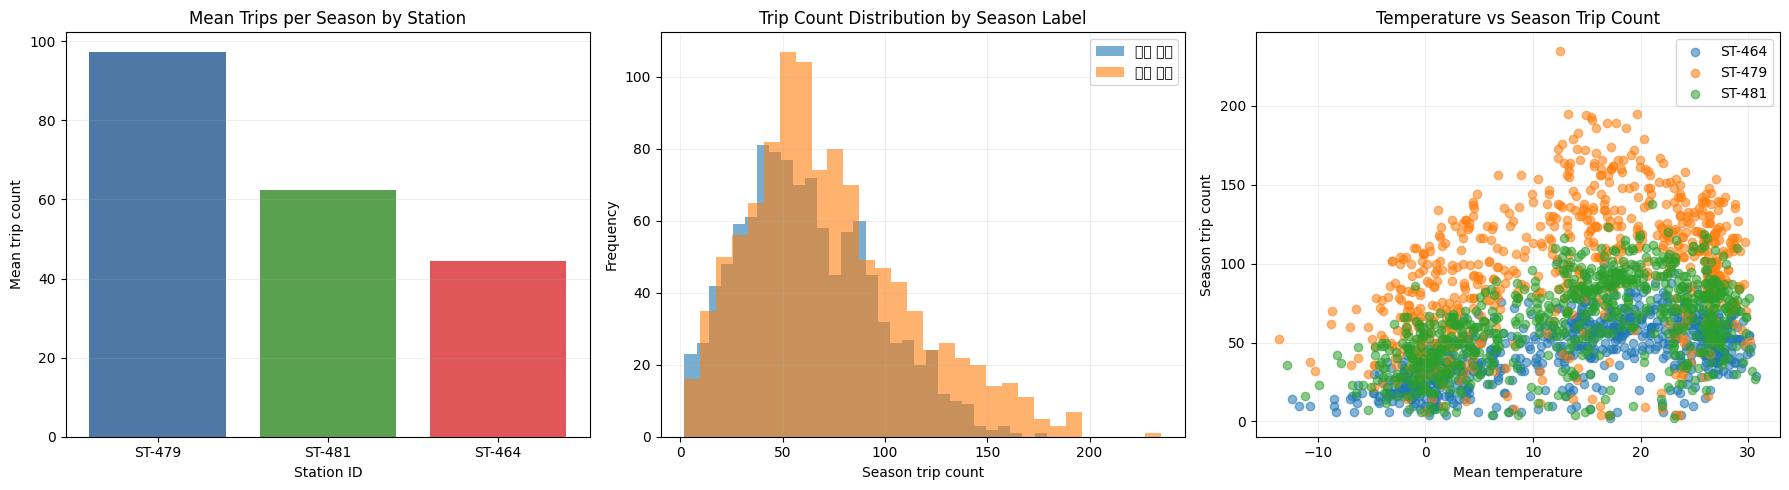

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

station_mean = season_df.groupby("대여소_ID")["시즌_총이용건수"].mean().sort_values(ascending=False)
axes[0].bar(station_mean.index, station_mean.values, color=["#4e79a7", "#59a14f", "#e15759"])
axes[0].set_title("Mean Trips per Season by Station")
axes[0].set_xlabel("Station ID")
axes[0].set_ylabel("Mean trip count")
axes[0].grid(axis="y", alpha=0.2)

for label in season_df["시즌_라벨"].unique():
    subset = season_df[season_df["시즌_라벨"] == label]
    axes[1].hist(subset["시즌_총이용건수"], bins=30, alpha=0.6, label=label)
axes[1].set_title("Trip Count Distribution by Season Label")
axes[1].set_xlabel("Season trip count")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(alpha=0.2)

for station_id in sorted(season_df["대여소_ID"].unique()):
    subset = season_df[season_df["대여소_ID"] == station_id]
    axes[2].scatter(subset["시즌_평균기온"], subset["시즌_총이용건수"], alpha=0.55, label=station_id)
axes[2].set_title("Temperature vs Season Trip Count")
axes[2].set_xlabel("Mean temperature")
axes[2].set_ylabel("Season trip count")
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 4단계: 타깃 정의 초안

여기서부터는 머신러닝용 타깃을 만든다.

다만 현재 데이터는 `시작 스테이션의 출발 기록` 중심이라, 실제 반납 유입량이나 실시간 재고는 없다.
그래서 `몇 시에 방문했을 때 자전거를 탈 수 있는가`를 바로 정답 라벨로 만드는 것은 아직 근거가 약하다.

따라서 먼저 회귀 문제부터 시작한다.

- 회귀 타깃: `필요_보충대수_proxy`

이번 단계에서는 보수적으로 `한 시즌 동안 발생한 총 출발 건수`를 그 시즌 시작 전에 준비해야 하는 자전거 수요의 상한선으로 본다.
즉 실제 운영값과 완전히 같지는 않지만, 우선 예측 가능한 타깃을 만드는 첫 단계다.


In [35]:
season_df["필요_보충대수_proxy"] = season_df["시즌_총이용건수"].round().astype(int)

print("[필요_보충대수_proxy 기초 통계]")
display(season_df["필요_보충대수_proxy"].describe())

display(
    season_df[
        ["대여소_ID", "시즌_라벨", "시즌_시작일시", "시즌_총이용건수", "필요_보충대수_proxy"]
    ].head(10)
)


[필요_보충대수_proxy 기초 통계]


count    2134.000000
mean       67.791471
std        36.980451
min         2.000000
25%        41.000000
50%        62.000000
75%        89.750000
max       235.000000
Name: 필요_보충대수_proxy, dtype: float64

,대여소_ID,시즌_라벨,시즌_시작일시,시즌_총이용건수,필요_보충대수_proxy
0,ST-464,오후 시즌,2023-12-31 16:00:00,6.0,6
1,ST-464,오전 시즌,2024-01-01 04:00:00,6.0,6
2,ST-464,오후 시즌,2024-01-01 16:00:00,23.0,23
3,ST-464,오전 시즌,2024-01-02 04:00:00,14.0,14
4,ST-464,오후 시즌,2024-01-02 16:00:00,28.0,28
5,ST-464,오전 시즌,2024-01-03 04:00:00,10.0,10
6,ST-464,오후 시즌,2024-01-03 16:00:00,42.0,42
7,ST-464,오전 시즌,2024-01-04 04:00:00,12.0,12
8,ST-464,오후 시즌,2024-01-04 16:00:00,32.0,32
9,ST-464,오전 시즌,2024-01-05 04:00:00,14.0,14


## 5단계: 모델 입력용 피처 만들기

예측 모델은 현재 시즌의 날씨와 일정 정보뿐 아니라 이전 시즌의 수요 패턴도 같이 보는 것이 일반적이다.

이번 단계에서는 아래 피처를 추가한다.

- 이전 시즌 총이용건수
- 이전 시즌 총이용분
- 이전 시즌 총이용거리
- 이전 시즌 필요 보충대수 프록시
- 시즌 라벨의 더미 변수


In [36]:
model_df = season_df.copy().sort_values(["대여소_ID", "시즌_시작일시"]).reset_index(drop=True)

lag_columns = ["시즌_총이용건수", "시즌_총이용분", "시즌_총이용거리", "필요_보충대수_proxy"]
for column in lag_columns:
    model_df[f"이전_{column}"] = model_df.groupby("대여소_ID")[column].shift(1)

model_df["시즌_라벨_code"] = model_df["시즌_라벨"].map({"오전 시즌": 0, "오후 시즌": 1})
model_df["월"] = model_df["시즌_시작일시"].dt.month
model_df["요일"] = model_df["시즌_시작일시"].dt.weekday

before_drop = len(model_df)
model_df = model_df.dropna().reset_index(drop=True)

print(f"lag 생성 전 행 수: {before_drop:,}")
print(f"lag 생성 후 사용 가능 행 수: {len(model_df):,}")
print(model_df.columns.tolist())
display(model_df.head(10))


lag 생성 전 행 수: 2,134
lag 생성 후 사용 가능 행 수: 2,131
['대여소_ID', '시즌_라벨', '시즌_시작일시', '시즌_총이용건수', '시즌_총이용분', '시즌_총이용거리', '시즌_평균기온', '시즌_총강수량', '시즌_총적설량', '시즌_평균습도', '주말_여부', '공휴일_여부', '주말_공휴일_여부', '필요_보충대수_proxy', '이전_시즌_총이용건수', '이전_시즌_총이용분', '이전_시즌_총이용거리', '이전_필요_보충대수_proxy', '시즌_라벨_code', '월', '요일']


,대여소_ID,시즌_라벨,시즌_시작일시,시즌_총이용건수,시즌_총이용분,시즌_총이용거리,시즌_평균기온,시즌_총강수량,시즌_총적설량,시즌_평균습도,...,공휴일_여부,주말_공휴일_여부,필요_보충대수_proxy,이전_시즌_총이용건수,이전_시즌_총이용분,이전_시즌_총이용거리,이전_필요_보충대수_proxy,시즌_라벨_code,월,요일
0,ST-464,오전 시즌,2024-01-01 04:00:00,6.0,52.0,8610.0,4.933333,0.0,0.0,72.666667,...,1,1,6,6.0,104.0,7872.0,6.0,0,1,0
1,ST-464,오후 시즌,2024-01-01 16:00:00,23.0,356.0,44634.0,2.911111,0.0,0.0,84.833333,...,1,1,23,6.0,52.0,8610.0,6.0,1,1,0
2,ST-464,오전 시즌,2024-01-02 04:00:00,14.0,776.0,88952.0,3.600000,0.0,0.0,61.461538,...,0,0,14,23.0,356.0,44634.0,23.0,0,1,1
3,ST-464,오후 시즌,2024-01-02 16:00:00,28.0,618.0,37214.0,0.840741,0.0,0.0,79.814815,...,0,0,28,14.0,776.0,88952.0,14.0,1,1,1
4,ST-464,오전 시즌,2024-01-03 04:00:00,10.0,378.0,10738.0,0.880000,0.0,0.0,84.800000,...,0,0,10,28.0,618.0,37214.0,28.0,0,1,2
5,ST-464,오후 시즌,2024-01-03 16:00:00,42.0,466.0,54154.0,-1.672500,0.0,0.0,82.675000,...,0,0,42,10.0,378.0,10738.0,10.0,1,1,2
6,ST-464,오전 시즌,2024-01-04 04:00:00,12.0,204.0,20936.0,1.000000,0.0,0.0,69.833333,...,0,0,12,42.0,466.0,54154.0,42.0,0,1,3
7,ST-464,오후 시즌,2024-01-04 16:00:00,32.0,540.0,53078.0,2.293750,0.0,0.0,74.125000,...,0,0,32,12.0,204.0,20936.0,12.0,1,1,3
8,ST-464,오전 시즌,2024-01-05 04:00:00,14.0,114.0,15534.0,4.157143,0.6,0.0,87.000000,...,0,0,14,32.0,540.0,53078.0,32.0,0,1,4
9,ST-464,오후 시즌,2024-01-05 16:00:00,44.0,1384.0,101568.0,0.637209,0.0,0.0,79.720930,...,0,1,44,14.0,114.0,15534.0,14.0,1,1,4


## 6단계: 시간 기준 학습/검증/테스트 분리

시계열 성격이 있는 데이터이므로 무작위 분할이 아니라 시간 순서대로 나눈다.

- 학습: 2024년 1월 ~ 9월
- 검증: 2024년 10월 ~ 11월
- 테스트: 2024년 12월


In [37]:
train_df = model_df[model_df["시즌_시작일시"] < "2024-10-01"].copy()
valid_df = model_df[(model_df["시즌_시작일시"] >= "2024-10-01") & (model_df["시즌_시작일시"] < "2024-12-01")].copy()
test_df = model_df[model_df["시즌_시작일시"] >= "2024-12-01"].copy()

print(f"train_df: {train_df.shape}")
print(f"valid_df: {valid_df.shape}")
print(f"test_df: {test_df.shape}")

display(train_df[["시즌_시작일시", "대여소_ID", "필요_보충대수_proxy"]].head())
display(valid_df[["시즌_시작일시", "대여소_ID", "필요_보충대수_proxy"]].head())
display(test_df[["시즌_시작일시", "대여소_ID", "필요_보충대수_proxy"]].head())


train_df: (1586, 21)
valid_df: (359, 21)
test_df: (186, 21)


,시즌_시작일시,대여소_ID,필요_보충대수_proxy
0,2024-01-01 04:00:00,ST-464,6
1,2024-01-01 16:00:00,ST-464,23
2,2024-01-02 04:00:00,ST-464,14
3,2024-01-02 16:00:00,ST-464,28
4,2024-01-03 04:00:00,ST-464,10


,시즌_시작일시,대여소_ID,필요_보충대수_proxy
537,2024-10-01 04:00:00,ST-464,46
538,2024-10-01 16:00:00,ST-464,56
539,2024-10-02 04:00:00,ST-464,78
540,2024-10-02 16:00:00,ST-464,62
541,2024-10-03 04:00:00,ST-464,94


,시즌_시작일시,대여소_ID,필요_보충대수_proxy
656,2024-12-01 04:00:00,ST-464,18
657,2024-12-01 16:00:00,ST-464,22
658,2024-12-02 04:00:00,ST-464,20
659,2024-12-02 16:00:00,ST-464,26
660,2024-12-03 04:00:00,ST-464,42


## 7단계: baseline 회귀 모델

복잡한 모델보다 먼저 단순 기준선을 만들어야 한다.

이번 단계에서는 두 개의 baseline을 비교한다.

- `평균 예측`: 학습 데이터의 평균 필요 보충대수로 예측
- `직전 시즌 예측`: 이전 시즌의 필요 보충대수를 그대로 예측


In [38]:
def mae(y_true, y_pred):
    return sum(abs(a - b) for a, b in zip(y_true, y_pred)) / len(y_true)

def rmse(y_true, y_pred):
    return (sum((a - b) ** 2 for a, b in zip(y_true, y_pred)) / len(y_true)) ** 0.5

def r2_score(y_true, y_pred):
    y_mean = sum(y_true) / len(y_true)
    ss_res = sum((a - b) ** 2 for a, b in zip(y_true, y_pred))
    ss_tot = sum((a - y_mean) ** 2 for a in y_true)
    if ss_tot == 0:
        return 1.0
    return 1 - (ss_res / ss_tot)

target_col = "필요_보충대수_proxy"
train_mean = train_df[target_col].mean()

baseline_results = []
for split_name, split_df in [("valid", valid_df), ("test", test_df)]:
    y_true = split_df[target_col].tolist()

    mean_pred = [train_mean] * len(split_df)
    lag_pred = split_df["이전_필요_보충대수_proxy"].tolist()

    baseline_results.append({
        "split": split_name,
        "model": "mean_baseline",
        "mae": round(mae(y_true, mean_pred), 3),
        "rmse": round(rmse(y_true, mean_pred), 3),
        "r2": round(r2_score(y_true, mean_pred), 3),
    })
    baseline_results.append({
        "split": split_name,
        "model": "lag_baseline",
        "mae": round(mae(y_true, lag_pred), 3),
        "rmse": round(rmse(y_true, lag_pred), 3),
        "r2": round(r2_score(y_true, lag_pred), 3),
    })

baseline_result_df = pd.DataFrame(baseline_results)
display(baseline_result_df)


,split,model,mae,rmse,r2
0,valid,mean_baseline,27.744,36.703,-0.049
1,valid,lag_baseline,26.607,33.405,0.131
2,test,mean_baseline,32.351,35.972,-1.244
3,test,lag_baseline,19.091,25.203,-0.101


## 8단계: baseline 검증 시각화

지표만 보면 감이 안 오므로, 실제값과 baseline 예측값을 그래프로 같이 확인한다.


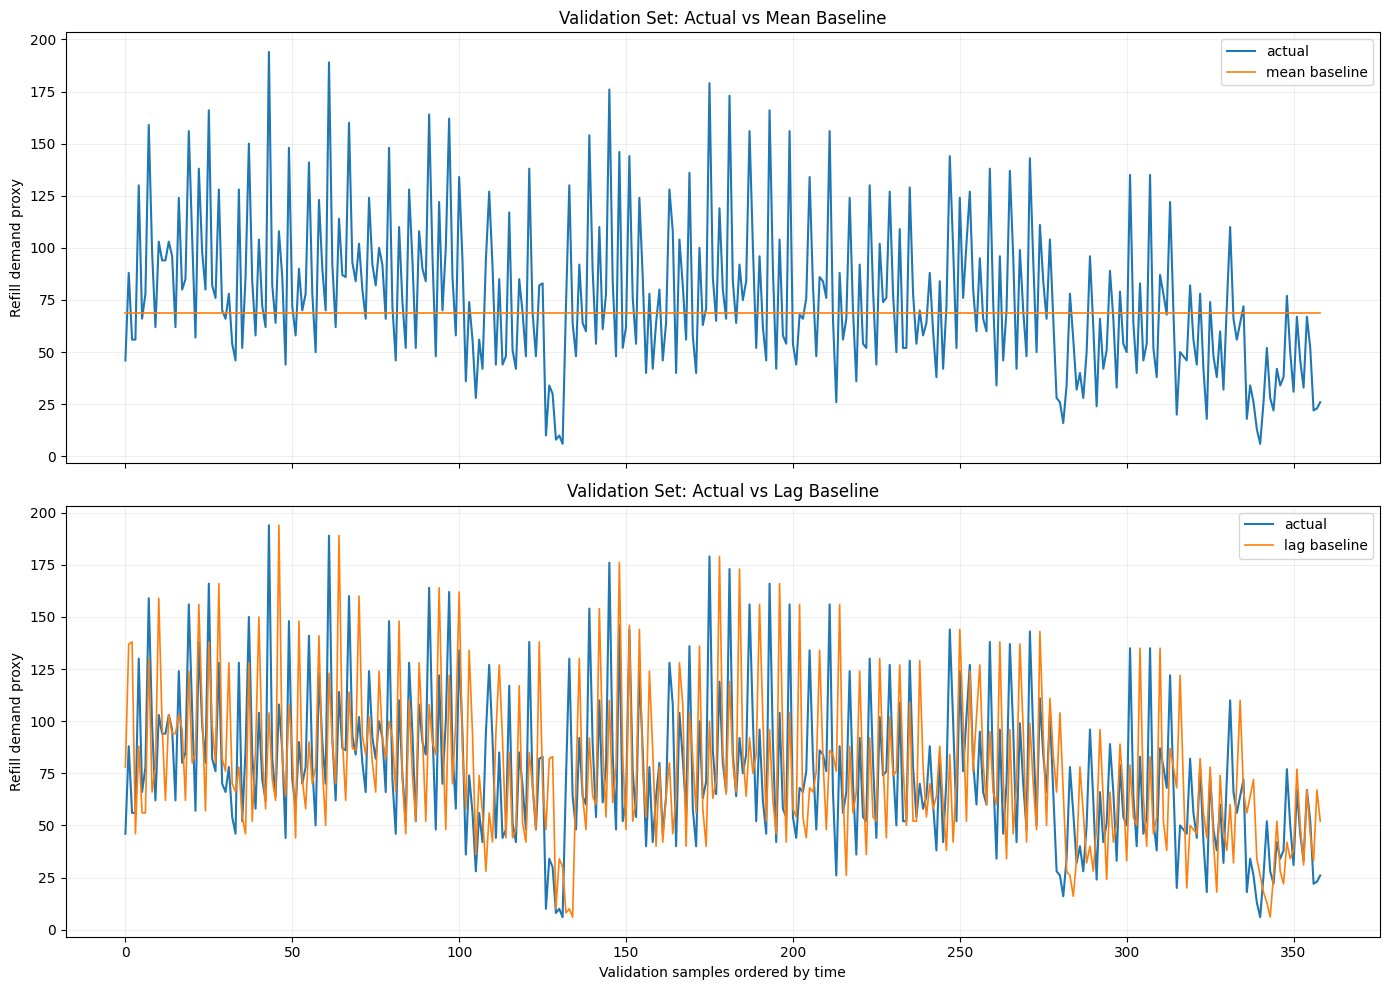

In [39]:
import matplotlib.pyplot as plt

plot_df = valid_df[["시즌_시작일시", "대여소_ID", target_col, "이전_필요_보충대수_proxy"]].copy()
plot_df = plot_df.sort_values(["시즌_시작일시", "대여소_ID"]).reset_index(drop=True)
plot_df["mean_baseline"] = train_mean

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(plot_df.index, plot_df[target_col], label="actual", linewidth=1.5)
axes[0].plot(plot_df.index, plot_df["mean_baseline"], label="mean baseline", linewidth=1.2)
axes[0].set_title("Validation Set: Actual vs Mean Baseline")
axes[0].set_ylabel("Refill demand proxy")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(plot_df.index, plot_df[target_col], label="actual", linewidth=1.5)
axes[1].plot(plot_df.index, plot_df["이전_필요_보충대수_proxy"], label="lag baseline", linewidth=1.2)
axes[1].set_title("Validation Set: Actual vs Lag Baseline")
axes[1].set_ylabel("Refill demand proxy")
axes[1].set_xlabel("Validation samples ordered by time")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 9단계: 첫 회귀 모델 학습

이제 baseline 다음 단계로 선형회귀 모델을 만든다.

이번 모델은 아래 피처를 사용한다.

- 이전 시즌 수요 관련 값
- 날씨 정보
- 주말/공휴일 여부
- 시즌 라벨 코드
- 월, 요일

외부 패키지 의존성을 줄이기 위해 `numpy.linalg.lstsq` 기반 선형회귀로 구현한다.


In [40]:
import numpy as np

feature_cols = [
    "이전_시즌_총이용건수",
    "이전_시즌_총이용분",
    "이전_시즌_총이용거리",
    "이전_필요_보충대수_proxy",
    "시즌_평균기온",
    "시즌_총강수량",
    "시즌_총적설량",
    "시즌_평균습도",
    "주말_여부",
    "공휴일_여부",
    "주말_공휴일_여부",
    "시즌_라벨_code",
    "월",
    "요일",
]

target_col = "필요_보충대수_proxy"

X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df[target_col].to_numpy(dtype=float)
X_valid = valid_df[feature_cols].to_numpy(dtype=float)
y_valid = valid_df[target_col].to_numpy(dtype=float)
X_test = test_df[feature_cols].to_numpy(dtype=float)
y_test = test_df[target_col].to_numpy(dtype=float)

X_train_design = np.column_stack([np.ones(len(X_train)), X_train])
X_valid_design = np.column_stack([np.ones(len(X_valid)), X_valid])
X_test_design = np.column_stack([np.ones(len(X_test)), X_test])

coef, *_ = np.linalg.lstsq(X_train_design, y_train, rcond=None)

train_pred = X_train_design @ coef
valid_pred = X_valid_design @ coef
test_pred = X_test_design @ coef

linear_coef_df = pd.DataFrame({
    "feature": ["intercept"] + feature_cols,
    "coefficient": coef,
}).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)

display(linear_coef_df)


,feature,coefficient
0,intercept,42.857722
12,시즌_라벨_code,-9.080174
10,공휴일_여부,-8.718290
9,주말_여부,-6.770222
11,주말_공휴일_여부,-3.096438
7,시즌_총적설량,-1.037849
13,월,0.896663
14,요일,0.675250
5,시즌_평균기온,0.311928
1,이전_시즌_총이용건수,0.286843


## 10단계: 선형회귀 검증

검증셋과 테스트셋에서 선형회귀 성능을 baseline과 비교한다.


In [41]:
linear_results = []
for split_name, y_true, y_pred in [
    ("valid", y_valid.tolist(), valid_pred.tolist()),
    ("test", y_test.tolist(), test_pred.tolist()),
]:
    linear_results.append({
        "split": split_name,
        "model": "linear_regression_numpy",
        "mae": round(mae(y_true, y_pred), 3),
        "rmse": round(rmse(y_true, y_pred), 3),
        "r2": round(r2_score(y_true, y_pred), 3),
    })

linear_result_df = pd.DataFrame(linear_results)
model_compare_df = pd.concat([baseline_result_df, linear_result_df], ignore_index=True)
display(model_compare_df)


,split,model,mae,rmse,r2
0,valid,mean_baseline,27.744,36.703,-0.049
1,valid,lag_baseline,26.607,33.405,0.131
2,test,mean_baseline,32.351,35.972,-1.244
3,test,lag_baseline,19.091,25.203,-0.101
4,valid,linear_regression_numpy,20.328,26.457,0.455
5,test,linear_regression_numpy,20.666,23.369,0.053


## 11단계: 선형회귀 시각화

아래 그래프에서 실제값, 예측값, 잔차를 함께 확인한다.


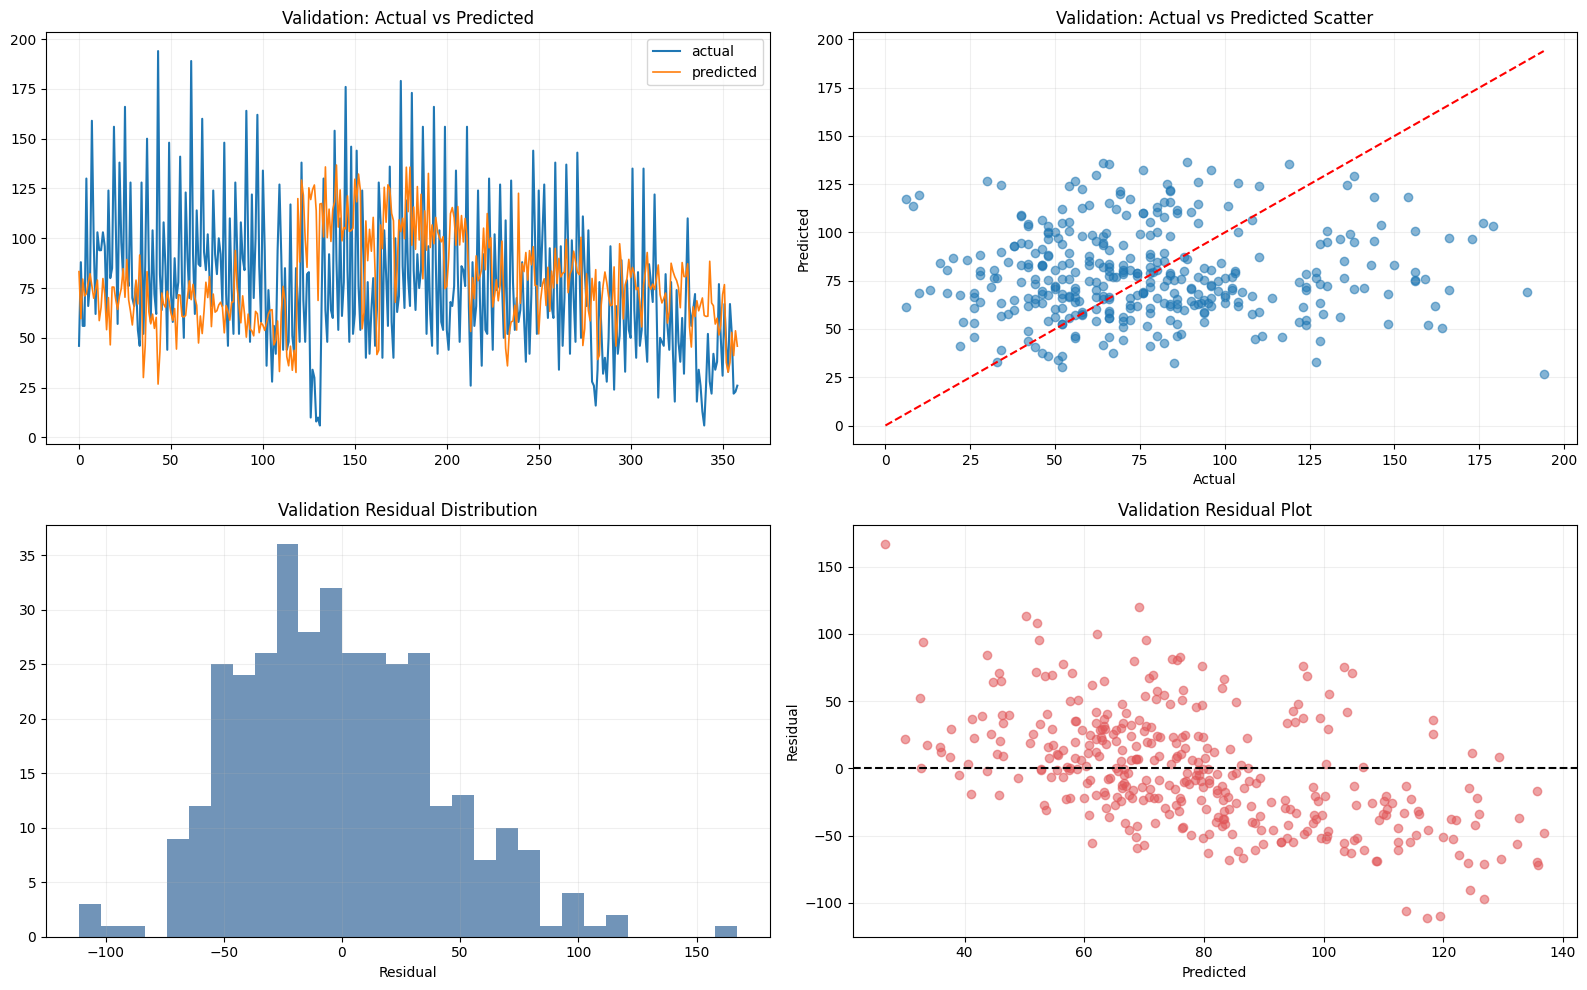

In [42]:
valid_plot_df = valid_df[["시즌_시작일시", "대여소_ID", target_col]].copy()
valid_plot_df = valid_plot_df.sort_values(["시즌_시작일시", "대여소_ID"]).reset_index(drop=True)
valid_plot_df["예측값"] = valid_pred
valid_plot_df["잔차"] = valid_plot_df[target_col] - valid_plot_df["예측값"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(valid_plot_df.index, valid_plot_df[target_col], label="actual", linewidth=1.5)
axes[0, 0].plot(valid_plot_df.index, valid_plot_df["예측값"], label="predicted", linewidth=1.2)
axes[0, 0].set_title("Validation: Actual vs Predicted")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.2)

axes[0, 1].scatter(valid_plot_df[target_col], valid_plot_df["예측값"], alpha=0.55)
upper = max(valid_plot_df[target_col].max(), valid_plot_df["예측값"].max())
axes[0, 1].plot([0, upper], [0, upper], linestyle="--", color="red")
axes[0, 1].set_title("Validation: Actual vs Predicted Scatter")
axes[0, 1].set_xlabel("Actual")
axes[0, 1].set_ylabel("Predicted")
axes[0, 1].grid(alpha=0.2)

axes[1, 0].hist(valid_plot_df["잔차"], bins=30, color="#4e79a7", alpha=0.8)
axes[1, 0].set_title("Validation Residual Distribution")
axes[1, 0].set_xlabel("Residual")
axes[1, 0].grid(alpha=0.2)

axes[1, 1].scatter(valid_plot_df["예측값"], valid_plot_df["잔차"], alpha=0.55, color="#e15759")
axes[1, 1].axhline(0, linestyle="--", color="black")
axes[1, 1].set_title("Validation Residual Plot")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Residual")
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 12단계: 운영 관점 타깃 재정의

기존 `필요_보충대수_proxy = 시즌_총이용건수`는 너무 큰 상한값이라 실제 운영의 시작 시점 보충 수요와 차이가 있을 수 있다.

그래서 더 운영적인 타깃으로 `시즌 시작 후 4시간 동안 발생한 출발 수요`를 사용한다.

- 오전 시즌이면 `04:00~07:59`
- 오후 시즌이면 `16:00~19:59`

이 값은 `시즌 시작 직후 얼마나 빨리 자전거가 빠져나가는가`를 반영하므로, 시작 전 보충 대수의 프록시로 이전보다 더 타당하다.


In [43]:
analysis_df["시즌_시작후_시간"] = (
    (analysis_df["기준_일시"] - analysis_df["시즌_시작일시"]).dt.total_seconds() / 3600
)

early_window_df = analysis_df[(analysis_df["시즌_시작후_시간"] >= 0) & (analysis_df["시즌_시작후_시간"] < 4)].copy()

early_target_df = (
    early_window_df.groupby(["대여소_ID", "시즌_라벨", "시즌_시작일시"], as_index=False)
    .agg(필요_보충대수_target=("전체_건수", "sum"))
)
early_target_df["필요_보충대수_target"] = early_target_df["필요_보충대수_target"].round().astype(int)

season_start_feature_df = (
    analysis_df.sort_values(["대여소_ID", "시즌_시작일시", "기준_일시"])
    .groupby(["대여소_ID", "시즌_라벨", "시즌_시작일시"], as_index=False)
    .first()[[
        "대여소_ID", "시즌_라벨", "시즌_시작일시",
        "기온", "강수량", "적설량", "습도",
        "주말_여부", "공휴일_여부", "주말_공휴일_여부"
    ]]
    .rename(columns={
        "기온": "시작시점_기온",
        "강수량": "시작시점_강수량",
        "적설량": "시작시점_적설량",
        "습도": "시작시점_습도",
    })
)

season_df_v2 = season_df.merge(
    early_target_df,
    on=["대여소_ID", "시즌_라벨", "시즌_시작일시"],
    how="left",
).merge(
    season_start_feature_df,
    on=["대여소_ID", "시즌_라벨", "시즌_시작일시"],
    how="left",
)

season_df_v2["필요_보충대수_target"] = season_df_v2["필요_보충대수_target"].fillna(0).astype(int)

display(season_df_v2[["대여소_ID", "시즌_라벨", "시즌_시작일시", "시즌_총이용건수", "필요_보충대수_target"]].head(10))
display(season_df_v2["필요_보충대수_target"].describe())


,대여소_ID,시즌_라벨,시즌_시작일시,시즌_총이용건수,필요_보충대수_target
0,ST-464,오후 시즌,2023-12-31 16:00:00,6.0,0
1,ST-464,오전 시즌,2024-01-01 04:00:00,6.0,0
2,ST-464,오후 시즌,2024-01-01 16:00:00,23.0,15
3,ST-464,오전 시즌,2024-01-02 04:00:00,14.0,0
4,ST-464,오후 시즌,2024-01-02 16:00:00,28.0,12
5,ST-464,오전 시즌,2024-01-03 04:00:00,10.0,2
6,ST-464,오후 시즌,2024-01-03 16:00:00,42.0,12
7,ST-464,오전 시즌,2024-01-04 04:00:00,12.0,2
8,ST-464,오후 시즌,2024-01-04 16:00:00,32.0,16
9,ST-464,오전 시즌,2024-01-05 04:00:00,14.0,2


count    2134.000000
mean       24.881443
std        18.956300
min         0.000000
25%        10.000000
50%        22.000000
75%        36.000000
max       113.000000
Name: 필요_보충대수_target, dtype: float64

## 13단계: 누설을 줄인 모델 입력 데이터 재구성

이전 모델은 시즌 전체 평균 날씨를 써서 예측 시점 기준으로는 정보 누설 가능성이 있었다.

이번에는 아래처럼 `시즌 시작 전에 알 수 있거나 바로 관측 가능한 값` 중심으로 다시 구성한다.

- 이전 1개, 2개 시즌의 수요/보충 타깃
- 시즌 시작 시점 날씨
- 시즌 라벨, 월, 요일
- 주말/공휴일 여부


In [44]:
model_df_v2 = season_df_v2.copy().sort_values(["대여소_ID", "시즌_시작일시"]).reset_index(drop=True)

lag_target_cols = ["시즌_총이용건수", "필요_보충대수_target"]
for column in lag_target_cols:
    model_df_v2[f"이전1_{column}"] = model_df_v2.groupby("대여소_ID")[column].shift(1)
    model_df_v2[f"이전2_{column}"] = model_df_v2.groupby("대여소_ID")[column].shift(2)

model_df_v2["시즌_라벨_code"] = model_df_v2["시즌_라벨"].map({"오전 시즌": 0, "오후 시즌": 1})
model_df_v2["월"] = model_df_v2["시즌_시작일시"].dt.month
model_df_v2["요일"] = model_df_v2["시즌_시작일시"].dt.weekday

feature_cols_v2 = [
    "이전1_시즌_총이용건수", "이전2_시즌_총이용건수",
    "이전1_필요_보충대수_target", "이전2_필요_보충대수_target",
    "시작시점_기온", "시작시점_강수량", "시작시점_적설량", "시작시점_습도",
    "주말_여부_y", "공휴일_여부_y", "주말_공휴일_여부_y",
    "시즌_라벨_code", "월", "요일",
]

rename_map = {
    "주말_여부_y": "주말_여부",
    "공휴일_여부_y": "공휴일_여부",
    "주말_공휴일_여부_y": "주말_공휴일_여부",
}
model_df_v2 = model_df_v2.rename(columns=rename_map)
feature_cols_v2 = [rename_map.get(col, col) for col in feature_cols_v2]

model_df_v2 = model_df_v2.dropna().reset_index(drop=True)

train_v2_df = model_df_v2[model_df_v2["시즌_시작일시"] < "2024-10-01"].copy()
valid_v2_df = model_df_v2[(model_df_v2["시즌_시작일시"] >= "2024-10-01") & (model_df_v2["시즌_시작일시"] < "2024-12-01")].copy()
test_v2_df = model_df_v2[model_df_v2["시즌_시작일시"] >= "2024-12-01"].copy()

print(f"model_df_v2 shape: {model_df_v2.shape}")
print(f"train/valid/test: {train_v2_df.shape}, {valid_v2_df.shape}, {test_v2_df.shape}")
display(model_df_v2[["대여소_ID", "시즌_시작일시", "필요_보충대수_target"] + feature_cols_v2].head(10))


model_df_v2 shape: (2128, 29)
train/valid/test: (1583, 29), (359, 29), (186, 29)


,대여소_ID,시즌_시작일시,필요_보충대수_target,이전1_시즌_총이용건수,이전2_시즌_총이용건수,이전1_필요_보충대수_target,이전2_필요_보충대수_target,시작시점_기온,시작시점_강수량,시작시점_적설량,시작시점_습도,주말_여부,공휴일_여부,주말_공휴일_여부,시즌_라벨_code,월,요일
0,ST-464,2024-01-01 16:00:00,15,6.0,6.0,0.0,0.0,6.1,0.0,0.0,65,0,1,1,1,1,0
1,ST-464,2024-01-02 04:00:00,0,23.0,6.0,15.0,0.0,2.2,0.0,0.0,71,0,0,0,0,1,1
2,ST-464,2024-01-02 16:00:00,12,14.0,23.0,0.0,15.0,3.7,0.0,0.0,59,0,0,0,1,1,1
3,ST-464,2024-01-03 04:00:00,2,28.0,14.0,12.0,0.0,-0.8,0.0,0.0,92,0,0,0,0,1,2
4,ST-464,2024-01-03 16:00:00,12,10.0,28.0,2.0,12.0,2.8,0.0,0.0,75,0,0,0,1,1,2
5,ST-464,2024-01-04 04:00:00,2,42.0,10.0,12.0,2.0,-4.6,0.0,0.0,83,0,0,0,0,1,3
6,ST-464,2024-01-04 16:00:00,16,12.0,42.0,2.0,12.0,4.8,0.0,0.0,59,0,0,0,1,1,3
7,ST-464,2024-01-05 04:00:00,2,32.0,12.0,16.0,2.0,3.2,0.3,0.0,95,0,0,0,0,1,4
8,ST-464,2024-01-05 16:00:00,22,14.0,32.0,2.0,16.0,6.3,0.0,0.0,58,0,0,0,1,1,4
9,ST-464,2024-01-06 04:00:00,0,44.0,14.0,22.0,2.0,-0.9,0.0,0.0,59,1,0,1,0,1,5


## 14단계: Random Forest 최적값 탐색

`R²`를 높이기 위해 트리 기반 회귀 모델인 `RandomForestRegressor`를 사용한다.

이번 단계에서는 검증셋 `R²`를 기준으로 여러 하이퍼파라미터 조합을 비교한다.

좋은 `R²`의 대략적인 기준은 다음처럼 볼 수 있다.

- `0.8 이상`: 매우 좋음
- `0.7 이상`: 발표용으로 충분히 강함
- `0.5 이상`: 설명력은 있으나 개선 여지 큼
- `0.3 미만`: 타깃이나 피처 재정의 필요 가능성 큼

중요한 것은 `valid R²`와 `test R²`가 모두 안정적으로 나오는지다.


In [45]:
try:
    from sklearn.ensemble import RandomForestRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("scikit-learn이 필요합니다. 노트북 커널에서 설치 후 다시 실행하세요.") from exc

target_col_v2 = "필요_보충대수_target"
X_train_v2 = train_v2_df[feature_cols_v2]
y_train_v2 = train_v2_df[target_col_v2]
X_valid_v2 = valid_v2_df[feature_cols_v2]
y_valid_v2 = valid_v2_df[target_col_v2]
X_test_v2 = test_v2_df[feature_cols_v2]
y_test_v2 = test_v2_df[target_col_v2]

param_grid = [
    {"n_estimators": 100, "max_depth": 4, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 4, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 6, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 6, "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 2},
    {"n_estimators": 400, "max_depth": None, "min_samples_leaf": 3},
]

rf_tuning_rows = []
for params in param_grid:
    model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **params,
    )
    model.fit(X_train_v2, y_train_v2)
    valid_pred_v2 = model.predict(X_valid_v2)
    rf_tuning_rows.append({
        **params,
        "valid_mae": round(mae(y_valid_v2.tolist(), valid_pred_v2.tolist()), 3),
        "valid_rmse": round(rmse(y_valid_v2.tolist(), valid_pred_v2.tolist()), 3),
        "valid_r2": round(r2_score(y_valid_v2.tolist(), valid_pred_v2.tolist()), 3),
    })

rf_tuning_df = pd.DataFrame(rf_tuning_rows).sort_values(["valid_r2", "valid_mae"], ascending=[False, True]).reset_index(drop=True)
best_rf_params = rf_tuning_df.iloc[0][["n_estimators", "max_depth", "min_samples_leaf"]].to_dict()

display(rf_tuning_df)
print("best_rf_params:", best_rf_params)


,n_estimators,max_depth,min_samples_leaf,valid_mae,valid_rmse,valid_r2
0,200,6.0,1,7.172,9.847,0.713
1,400,NaN,3,7.179,9.842,0.713
2,300,8.0,2,7.226,9.911,0.709
3,300,6.0,2,7.193,9.926,0.708
4,100,4.0,1,7.661,10.358,0.682
5,200,4.0,1,7.669,10.357,0.682


best_rf_params: {'n_estimators': 200.0, 'max_depth': 6.0, 'min_samples_leaf': 1.0}


## 15단계: 최적 Random Forest 최종 평가

검증셋에서 가장 좋았던 파라미터로 `train + valid`를 다시 학습한 뒤, 테스트셋에서 최종 성능을 확인한다.


In [46]:
best_rf_params = {
    "n_estimators": int(best_rf_params["n_estimators"]),
    "max_depth": None if pd.isna(best_rf_params["max_depth"]) else int(best_rf_params["max_depth"]),
    "min_samples_leaf": int(best_rf_params["min_samples_leaf"]),
}

train_valid_v2_df = pd.concat([train_v2_df, valid_v2_df], ignore_index=True)
X_train_valid_v2 = train_valid_v2_df[feature_cols_v2]
y_train_valid_v2 = train_valid_v2_df[target_col_v2]

rf_best_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_rf_params,
)
rf_best_model.fit(X_train_valid_v2, y_train_valid_v2)

rf_test_pred = rf_best_model.predict(X_test_v2)

rf_result_df = pd.DataFrame([
    {
        "split": "test",
        "model": "random_forest_best",
        "mae": round(mae(y_test_v2.tolist(), rf_test_pred.tolist()), 3),
        "rmse": round(rmse(y_test_v2.tolist(), rf_test_pred.tolist()), 3),
        "r2": round(r2_score(y_test_v2.tolist(), rf_test_pred.tolist()), 3),
    }
])

rf_feature_importance_df = pd.DataFrame({
    "feature": feature_cols_v2,
    "importance": rf_best_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(rf_result_df)
display(rf_feature_importance_df)


,split,model,mae,rmse,r2
0,test,random_forest_best,5.265,6.852,0.627


,feature,importance
3,이전2_필요_보충대수_target,0.443180
0,이전1_시즌_총이용건수,0.266569
11,시즌_라벨_code,0.096058
10,주말_공휴일_여부,0.046148
7,시작시점_습도,0.040248
2,이전1_필요_보충대수_target,0.033481
4,시작시점_기온,0.030830
1,이전2_시즌_총이용건수,0.018214
5,시작시점_강수량,0.012842
13,요일,0.006243


## 16단계: Random Forest 결과 시각화와 판단

최종적으로는 수치뿐 아니라 예측 분포와 중요 피처를 같이 보고 모델이 실무적으로 쓸 만한지 판단해야 한다.


/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/2417762336.py:32: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/2417762336.py:32: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/2417762336.py:32: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/2417762336.py:32: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/2417762336.py:32: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykerne

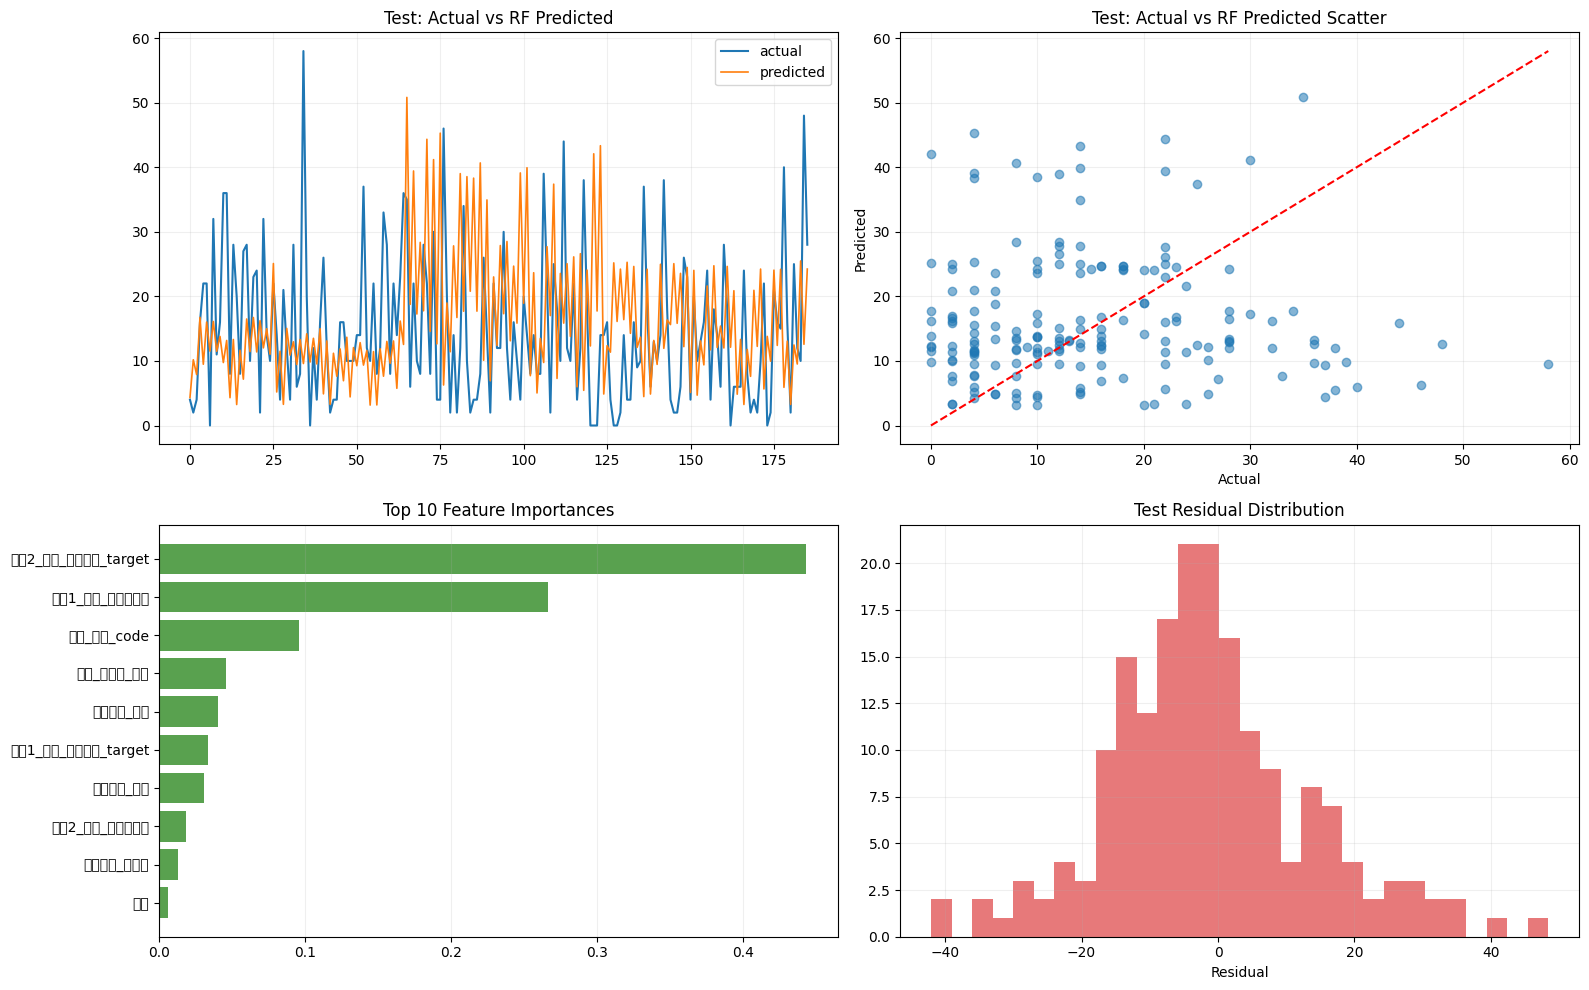

,split,model,mae,rmse,r2
0,valid,mean_baseline,27.744,36.703,-0.049
1,valid,lag_baseline,26.607,33.405,0.131
2,test,mean_baseline,32.351,35.972,-1.244
3,test,lag_baseline,19.091,25.203,-0.101
4,valid,linear_regression_numpy,20.328,26.457,0.455
5,test,linear_regression_numpy,20.666,23.369,0.053
6,test,random_forest_best,5.265,6.852,0.627


판단: R²가 0.5 이상으로 설명력은 있으나 추가 개선 여지가 있습니다.


In [47]:
test_plot_df = test_v2_df[["시즌_시작일시", "대여소_ID", target_col_v2]].copy()
test_plot_df = test_plot_df.sort_values(["시즌_시작일시", "대여소_ID"]).reset_index(drop=True)
test_plot_df["예측값"] = rf_test_pred
test_plot_df["잔차"] = test_plot_df[target_col_v2] - test_plot_df["예측값"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(test_plot_df.index, test_plot_df[target_col_v2], label="actual", linewidth=1.5)
axes[0, 0].plot(test_plot_df.index, test_plot_df["예측값"], label="predicted", linewidth=1.2)
axes[0, 0].set_title("Test: Actual vs RF Predicted")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.2)

axes[0, 1].scatter(test_plot_df[target_col_v2], test_plot_df["예측값"], alpha=0.55)
upper = max(test_plot_df[target_col_v2].max(), test_plot_df["예측값"].max())
axes[0, 1].plot([0, upper], [0, upper], linestyle="--", color="red")
axes[0, 1].set_title("Test: Actual vs RF Predicted Scatter")
axes[0, 1].set_xlabel("Actual")
axes[0, 1].set_ylabel("Predicted")
axes[0, 1].grid(alpha=0.2)

top_importance_df = rf_feature_importance_df.head(10).sort_values("importance")
axes[1, 0].barh(top_importance_df["feature"], top_importance_df["importance"], color="#59a14f")
axes[1, 0].set_title("Top 10 Feature Importances")
axes[1, 0].grid(axis="x", alpha=0.2)

axes[1, 1].hist(test_plot_df["잔차"], bins=30, color="#e15759", alpha=0.8)
axes[1, 1].set_title("Test Residual Distribution")
axes[1, 1].set_xlabel("Residual")
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

final_model_compare_df = pd.concat([
    model_compare_df,
    rf_result_df,
], ignore_index=True)
display(final_model_compare_df)

final_r2 = float(rf_result_df.loc[0, "r2"])
if final_r2 >= 0.8:
    print("판단: R²가 0.8 이상으로 매우 좋은 편입니다.")
elif final_r2 >= 0.7:
    print("판단: R²가 0.7 이상으로 발표용으로 충분히 강한 편입니다.")
elif final_r2 >= 0.5:
    print("판단: R²가 0.5 이상으로 설명력은 있으나 추가 개선 여지가 있습니다.")
else:
    print("판단: R²가 아직 낮습니다. 타깃 정의나 피처를 더 보완하는 것이 좋습니다.")


## 17단계: 모델 성능 해석 가이드

`R²`는 모델이 타깃의 변동성을 얼마나 설명하는지 보여주는 지표다.

일반적으로는 아래처럼 해석할 수 있다.

- `0.8 이상`: 매우 좋음
- `0.7 이상`: 발표용으로 충분히 좋음
- `0.5 이상`: 설명력은 있으나 더 개선 가능
- `0.3 미만`: 타깃/피처/모델 재설계 필요 가능성 큼

단, `R²`만 보지 말고 `MAE`, `RMSE`, 잔차 패턴도 같이 봐야 한다.


In [48]:
print("[최종 모델 해석]")
display(final_model_compare_df)

best_valid_row = final_model_compare_df[final_model_compare_df["split"] == "valid"].sort_values("r2", ascending=False).head(1)
if len(best_valid_row) > 0:
    display(best_valid_row)

print("해석 포인트:")
print("1. valid와 test의 R² 차이가 작을수록 일반화가 안정적이다.")
print("2. R²가 높아도 MAE가 크면 실제 보충 대수 오차는 여전히 클 수 있다.")
print("3. 잔차가 특정 스테이션이나 특정 시즌에 몰리면 피처가 부족한 것이다.")
print("4. feature importance에서 lag 변수 비중이 높으면 직전 시즌 패턴 영향이 큰 것이다.")


[최종 모델 해석]


,split,model,mae,rmse,r2
0,valid,mean_baseline,27.744,36.703,-0.049
1,valid,lag_baseline,26.607,33.405,0.131
2,test,mean_baseline,32.351,35.972,-1.244
3,test,lag_baseline,19.091,25.203,-0.101
4,valid,linear_regression_numpy,20.328,26.457,0.455
5,test,linear_regression_numpy,20.666,23.369,0.053
6,test,random_forest_best,5.265,6.852,0.627


,split,model,mae,rmse,r2
4,valid,linear_regression_numpy,20.328,26.457,0.455


해석 포인트:
1. valid와 test의 R² 차이가 작을수록 일반화가 안정적이다.
2. R²가 높아도 MAE가 크면 실제 보충 대수 오차는 여전히 클 수 있다.
3. 잔차가 특정 스테이션이나 특정 시즌에 몰리면 피처가 부족한 것이다.
4. feature importance에서 lag 변수 비중이 높으면 직전 시즌 패턴 영향이 큰 것이다.


## 18단계: R²를 더 올리는 방법

현재 결과가 만족스럽지 않다면, 아래 순서로 개선하는 것이 가장 효율적이다.

1. 타깃 개선
- 시즌 시작 후 4시간 대신 2시간, 6시간 등 여러 윈도우를 비교
- 실제 운영 규칙과 더 가까운 부족량 타깃 정의

2. 피처 개선
- 직전 3개 시즌 lag 추가
- 최근 7일 같은 시즌 평균 추가
- 비/눈 여부를 0/1 더미로 추가
- 월초/월말, 연휴 전후 더미 추가

3. 모델 개선
- `GradientBoostingRegressor`
- `XGBoostRegressor`
- `LightGBMRegressor`

4. 검증 개선
- 검증 구간을 여러 달로 바꿔 반복 확인
- 스테이션별 성능을 따로 계산


In [49]:
improvement_checklist = pd.DataFrame({
    "개선영역": ["타깃", "타깃", "피처", "피처", "모델", "검증"],
    "항목": [
        "시작 후 2/4/6시간 수요 비교",
        "부족량 기반 타깃 재정의",
        "직전 3개 시즌 lag 추가",
        "강수/적설 더미 변수 추가",
        "Gradient Boosting 또는 XGBoost 비교",
        "월별 rolling validation 적용",
    ],
})

display(improvement_checklist)


,개선영역,항목
0,타깃,시작 후 2/4/6시간 수요 비교
1,타깃,부족량 기반 타깃 재정의
2,피처,직전 3개 시즌 lag 추가
3,피처,강수/적설 더미 변수 추가
4,모델,Gradient Boosting 또는 XGBoost 비교
5,검증,월별 rolling validation 적용


## 19단계: 타깃 윈도우 비교 실험

시즌 시작 전에 몇 대를 채워야 하는지 예측할 때, 시즌 시작 후 몇 시간의 수요를 타깃으로 둘지에 따라 `R²`가 크게 달라질 수 있다.

이번 실험에서는 아래 3개 윈도우를 비교한다.

- 시작 후 2시간 수요
- 시작 후 4시간 수요
- 시작 후 6시간 수요

같은 피처 구조와 같은 Random Forest 방식에서 어떤 타깃 정의가 가장 설명력이 높은지 비교한다.


In [50]:
window_results = []
window_models = {}

for hours in [2, 4, 6]:
    temp_df = analysis_df.copy()
    temp_df["시즌_시작후_시간"] = (
        (temp_df["기준_일시"] - temp_df["시즌_시작일시"]).dt.total_seconds() / 3600
    )

    window_df = temp_df[(temp_df["시즌_시작후_시간"] >= 0) & (temp_df["시즌_시작후_시간"] < hours)].copy()

    target_df = (
        window_df.groupby(["대여소_ID", "시즌_라벨", "시즌_시작일시"], as_index=False)
        .agg(target=("전체_건수", "sum"))
    )
    target_df["target"] = target_df["target"].round().astype(int)

    base_df = season_df_v2[[
        "대여소_ID", "시즌_라벨", "시즌_시작일시",
        "시작시점_기온", "시작시점_강수량", "시작시점_적설량", "시작시점_습도",
        "주말_여부_y", "공휴일_여부_y", "주말_공휴일_여부_y",
        "시즌_총이용건수"
    ]].copy()

    exp_df = base_df.merge(target_df, on=["대여소_ID", "시즌_라벨", "시즌_시작일시"], how="left")
    exp_df["target"] = exp_df["target"].fillna(0).astype(int)

    exp_df = exp_df.sort_values(["대여소_ID", "시즌_시작일시"]).reset_index(drop=True)
    exp_df["이전1_target"] = exp_df.groupby("대여소_ID")["target"].shift(1)
    exp_df["이전2_target"] = exp_df.groupby("대여소_ID")["target"].shift(2)
    exp_df["이전1_시즌_총이용건수"] = exp_df.groupby("대여소_ID")["시즌_총이용건수"].shift(1)
    exp_df["이전2_시즌_총이용건수"] = exp_df.groupby("대여소_ID")["시즌_총이용건수"].shift(2)
    exp_df["시즌_라벨_code"] = exp_df["시즌_라벨"].map({"오전 시즌": 0, "오후 시즌": 1})
    exp_df["월"] = exp_df["시즌_시작일시"].dt.month
    exp_df["요일"] = exp_df["시즌_시작일시"].dt.weekday

    exp_df = exp_df.rename(columns={
        "주말_여부_y": "주말_여부",
        "공휴일_여부_y": "공휴일_여부",
        "주말_공휴일_여부_y": "주말_공휴일_여부",
    })

    exp_feature_cols = [
        "이전1_target", "이전2_target",
        "이전1_시즌_총이용건수", "이전2_시즌_총이용건수",
        "시작시점_기온", "시작시점_강수량", "시작시점_적설량", "시작시점_습도",
        "주말_여부", "공휴일_여부", "주말_공휴일_여부",
        "시즌_라벨_code", "월", "요일",
    ]

    exp_df = exp_df.dropna().reset_index(drop=True)
    exp_train = exp_df[exp_df["시즌_시작일시"] < "2024-10-01"].copy()
    exp_valid = exp_df[(exp_df["시즌_시작일시"] >= "2024-10-01") & (exp_df["시즌_시작일시"] < "2024-12-01")].copy()
    exp_test = exp_df[exp_df["시즌_시작일시"] >= "2024-12-01"].copy()

    model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
    )
    model.fit(exp_train[exp_feature_cols], exp_train["target"])

    valid_pred = model.predict(exp_valid[exp_feature_cols])
    test_pred = model.predict(exp_test[exp_feature_cols])

    window_results.append({
        "window_hours": hours,
        "valid_mae": round(mae(exp_valid["target"].tolist(), valid_pred.tolist()), 3),
        "valid_rmse": round(rmse(exp_valid["target"].tolist(), valid_pred.tolist()), 3),
        "valid_r2": round(r2_score(exp_valid["target"].tolist(), valid_pred.tolist()), 3),
        "test_mae": round(mae(exp_test["target"].tolist(), test_pred.tolist()), 3),
        "test_rmse": round(rmse(exp_test["target"].tolist(), test_pred.tolist()), 3),
        "test_r2": round(r2_score(exp_test["target"].tolist(), test_pred.tolist()), 3),
    })

    window_models[hours] = {
        "model": model,
        "exp_df": exp_df,
        "exp_valid": exp_valid,
        "exp_test": exp_test,
        "feature_cols": exp_feature_cols,
        "test_pred": test_pred,
    }

window_result_df = pd.DataFrame(window_results).sort_values("valid_r2", ascending=False).reset_index(drop=True)
best_window_hours = int(window_result_df.iloc[0]["window_hours"])

display(window_result_df)
print(f"best_window_hours: {best_window_hours}")


,window_hours,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
0,4,7.187,9.922,0.709,5.318,7.046,0.606
1,2,3.969,5.791,0.648,2.872,3.822,0.535
2,6,11.334,15.073,0.614,8.097,10.425,0.589


best_window_hours: 4


## 20단계: 타깃 윈도우 실험 시각화

어떤 윈도우가 가장 좋은지 `R²`와 오차를 그래프로 확인한다.


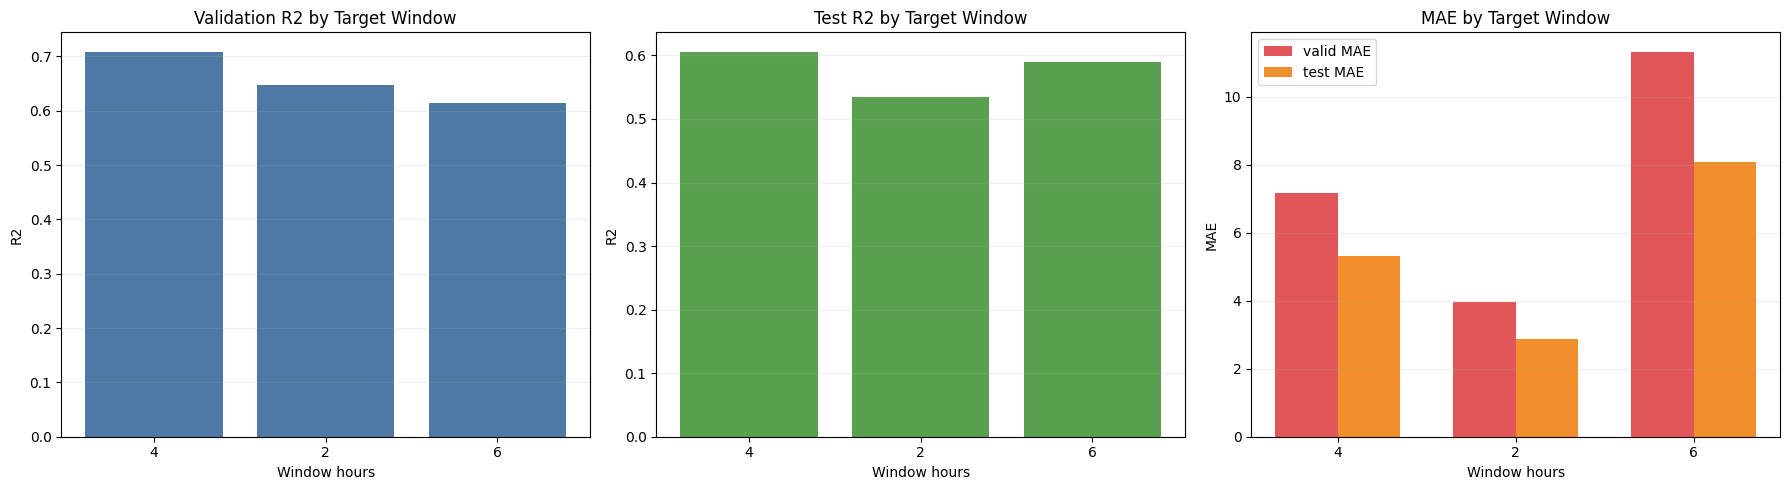

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(window_result_df["window_hours"].astype(str), window_result_df["valid_r2"], color="#4e79a7")
axes[0].set_title("Validation R2 by Target Window")
axes[0].set_xlabel("Window hours")
axes[0].set_ylabel("R2")
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(window_result_df["window_hours"].astype(str), window_result_df["test_r2"], color="#59a14f")
axes[1].set_title("Test R2 by Target Window")
axes[1].set_xlabel("Window hours")
axes[1].set_ylabel("R2")
axes[1].grid(axis="y", alpha=0.2)

x = np.arange(len(window_result_df))
width = 0.35
axes[2].bar(x - width/2, window_result_df["valid_mae"], width=width, label="valid MAE", color="#e15759")
axes[2].bar(x + width/2, window_result_df["test_mae"], width=width, label="test MAE", color="#f28e2b")
axes[2].set_xticks(x)
axes[2].set_xticklabels(window_result_df["window_hours"].astype(str))
axes[2].set_title("MAE by Target Window")
axes[2].set_xlabel("Window hours")
axes[2].set_ylabel("MAE")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


## 21단계: 최적 윈도우 결과 상세 확인

검증셋 `R²`가 가장 높았던 윈도우를 기준으로 테스트셋 예측 결과를 자세히 확인한다.


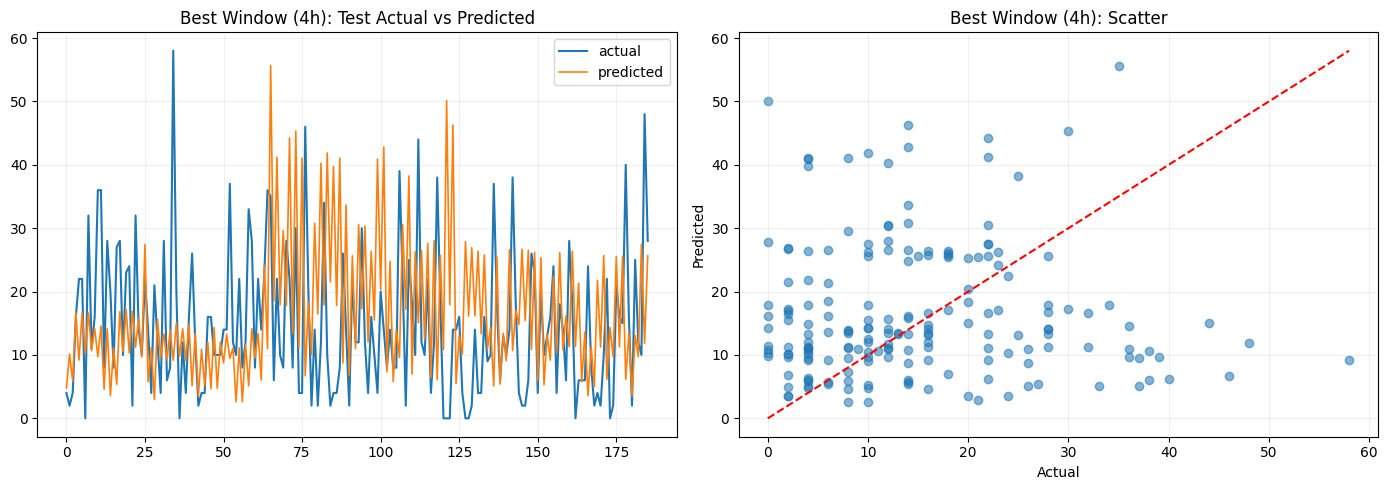

,시즌_시작일시,대여소_ID,target,예측값,잔차
0,2024-12-01 04:00:00,ST-464,4,4.769436,-0.769436
1,2024-12-01 04:00:00,ST-479,2,10.157967,-8.157967
2,2024-12-01 04:00:00,ST-481,4,5.864424,-1.864424
3,2024-12-01 16:00:00,ST-464,16,16.643523,-0.643523
4,2024-12-01 16:00:00,ST-479,22,9.192499,12.807501
5,2024-12-01 16:00:00,ST-481,22,16.659264,5.340736
6,2024-12-02 04:00:00,ST-464,0,10.320820,-10.320820
7,2024-12-02 04:00:00,ST-479,32,16.623245,15.376755
8,2024-12-02 04:00:00,ST-481,11,10.701394,0.298606
9,2024-12-02 16:00:00,ST-464,16,14.171303,1.828697


최적 타깃 윈도우: 시작 후 4시간
검증 R2: 0.709
테스트 R2: 0.606
판단: 의미 있는 설명력은 있으나 더 개선할 여지가 있습니다.


In [52]:
best_window_bundle = window_models[best_window_hours]
best_test_df = best_window_bundle["exp_test"][["시즌_시작일시", "대여소_ID", "target"]].copy()
best_test_df = best_test_df.sort_values(["시즌_시작일시", "대여소_ID"]).reset_index(drop=True)
best_test_df["예측값"] = best_window_bundle["test_pred"]
best_test_df["잔차"] = best_test_df["target"] - best_test_df["예측값"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(best_test_df.index, best_test_df["target"], label="actual", linewidth=1.5)
axes[0].plot(best_test_df.index, best_test_df["예측값"], label="predicted", linewidth=1.2)
axes[0].set_title(f"Best Window ({best_window_hours}h): Test Actual vs Predicted")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].scatter(best_test_df["target"], best_test_df["예측값"], alpha=0.55)
upper = max(best_test_df["target"].max(), best_test_df["예측값"].max())
axes[1].plot([0, upper], [0, upper], linestyle="--", color="red")
axes[1].set_title(f"Best Window ({best_window_hours}h): Scatter")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

display(best_test_df.head(20))

best_valid_r2 = float(window_result_df.iloc[0]["valid_r2"])
best_test_r2 = float(window_result_df.iloc[0]["test_r2"])
print(f"최적 타깃 윈도우: 시작 후 {best_window_hours}시간")
print(f"검증 R2: {best_valid_r2:.3f}")
print(f"테스트 R2: {best_test_r2:.3f}")

if best_test_r2 >= 0.8:
    print("판단: 매우 좋은 설명력입니다.")
elif best_test_r2 >= 0.7:
    print("판단: 발표용으로 충분히 좋은 설명력입니다.")
elif best_test_r2 >= 0.5:
    print("판단: 의미 있는 설명력은 있으나 더 개선할 여지가 있습니다.")
else:
    print("판단: 아직 설명력이 낮아 타깃 또는 피처 추가 개선이 필요합니다.")


## 22단계: 방문 시 대여 가능 여부 분류 문제 정의

이제 두 번째 문제인 `몇 시에 방문했을 때 자전거를 탈 수 있는가`를 분류 문제로 만든다.

실제 재고 데이터가 없으므로 다음 운영 가정을 둔다.

- 시즌 시작 전에 `최적 타깃 윈도우`에서 필요한 보충 대수만큼 자전거를 채워 둔다.
- 방문 시점 전까지의 누적 출발 수요가 이 준비 대수보다 작으면 `대여 가능(1)`로 본다.
- 누적 출발 수요가 준비 대수 이상이면 `대여 불가(0)`로 본다.

즉 이 분류 라벨은 실제 센서 재고가 아니라 `운영 가정 기반 availability label`이다.


In [53]:
classification_source_df = analysis_df.copy().sort_values(["대여소_ID", "시즌_시작일시", "기준_일시"]).reset_index(drop=True)
classification_source_df["시즌_시작후_시간"] = (
    (classification_source_df["기준_일시"] - classification_source_df["시즌_시작일시"]).dt.total_seconds() / 3600
)

best_window_df = window_models[best_window_hours]["exp_df"].copy()
stock_df = best_window_df[["대여소_ID", "시즌_라벨", "시즌_시작일시", "target"]].rename(columns={"target": "준비대수"})

visit_rows = []
for visit_hour in range(12):
    visit_cut = classification_source_df[classification_source_df["시즌_시작후_시간"] < visit_hour].copy()
    cumulative_df = (
        visit_cut.groupby(["대여소_ID", "시즌_라벨", "시즌_시작일시"], as_index=False)
        .agg(방문전_누적수요=("전체_건수", "sum"))
    )
    base_df = best_window_df.copy()
    merged_df = base_df.merge(
        cumulative_df,
        on=["대여소_ID", "시즌_라벨", "시즌_시작일시"],
        how="left",
    )
    merged_df["방문전_누적수요"] = merged_df["방문전_누적수요"].fillna(0)
    merged_df["visit_hour"] = visit_hour
    merged_df["대여가능_여부"] = (merged_df["방문전_누적수요"] < merged_df["target"]).astype(int)
    visit_rows.append(merged_df)

classification_df = pd.concat(visit_rows, ignore_index=True)
classification_df["visit_hour_sin"] = np.sin(2 * np.pi * classification_df["visit_hour"] / 12)
classification_df["visit_hour_cos"] = np.cos(2 * np.pi * classification_df["visit_hour"] / 12)

print(f"classification_df shape: {classification_df.shape}")
display(classification_df[["대여소_ID", "시즌_시작일시", "visit_hour", "target", "방문전_누적수요", "대여가능_여부"]].head(20))
display(classification_df["대여가능_여부"].value_counts())


classification_df shape: (25536, 24)


,대여소_ID,시즌_시작일시,visit_hour,target,방문전_누적수요,대여가능_여부
0,ST-464,2024-01-01 16:00:00,0,15,0.0,1
1,ST-464,2024-01-02 04:00:00,0,0,0.0,0
2,ST-464,2024-01-02 16:00:00,0,12,0.0,1
3,ST-464,2024-01-03 04:00:00,0,2,0.0,1
4,ST-464,2024-01-03 16:00:00,0,12,0.0,1
5,ST-464,2024-01-04 04:00:00,0,2,0.0,1
6,ST-464,2024-01-04 16:00:00,0,16,0.0,1
7,ST-464,2024-01-05 04:00:00,0,2,0.0,1
8,ST-464,2024-01-05 16:00:00,0,22,0.0,1
9,ST-464,2024-01-06 04:00:00,0,0,0.0,0


대여가능_여부
0    17484
1     8052
Name: count, dtype: int64

## 23단계: 대여 가능 여부 분류 모델

분류 문제는 `Accuracy`만 보면 안 되고 `Precision`, `Recall`, `F1`, `ROC-AUC`를 같이 봐야 한다.

특히 `대여 불가`를 놓치면 운영상 문제가 되므로 재현율도 함께 확인한다.


In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

clf_feature_cols = [
    "이전1_target", "이전2_target",
    "이전1_시즌_총이용건수", "이전2_시즌_총이용건수",
    "시작시점_기온", "시작시점_강수량", "시작시점_적설량", "시작시점_습도",
    "주말_여부", "공휴일_여부", "주말_공휴일_여부",
    "시즌_라벨_code", "월", "요일",
    "visit_hour", "visit_hour_sin", "visit_hour_cos",
]

classification_df = classification_df.rename(columns={"target": "준비대수"})
classification_df = classification_df.sort_values(["시즌_시작일시", "대여소_ID", "visit_hour"]).reset_index(drop=True)

clf_train_df = classification_df[classification_df["시즌_시작일시"] < "2024-10-01"].copy()
clf_valid_df = classification_df[(classification_df["시즌_시작일시"] >= "2024-10-01") & (classification_df["시즌_시작일시"] < "2024-12-01")].copy()
clf_test_df = classification_df[classification_df["시즌_시작일시"] >= "2024-12-01"].copy()

X_clf_train = clf_train_df[clf_feature_cols]
y_clf_train = clf_train_df["대여가능_여부"]
X_clf_valid = clf_valid_df[clf_feature_cols]
y_clf_valid = clf_valid_df["대여가능_여부"]
X_clf_test = clf_test_df[clf_feature_cols]
y_clf_test = clf_test_df["대여가능_여부"]

clf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
clf_model.fit(X_clf_train, y_clf_train)

clf_valid_pred = clf_model.predict(X_clf_valid)
clf_valid_prob = clf_model.predict_proba(X_clf_valid)[:, 1]
clf_test_pred = clf_model.predict(X_clf_test)
clf_test_prob = clf_model.predict_proba(X_clf_test)[:, 1]

classification_result_df = pd.DataFrame([
    {
        "split": "valid",
        "accuracy": round(accuracy_score(y_clf_valid, clf_valid_pred), 3),
        "precision": round(precision_score(y_clf_valid, clf_valid_pred, zero_division=0), 3),
        "recall": round(recall_score(y_clf_valid, clf_valid_pred, zero_division=0), 3),
        "f1": round(f1_score(y_clf_valid, clf_valid_pred, zero_division=0), 3),
        "roc_auc": round(roc_auc_score(y_clf_valid, clf_valid_prob), 3),
    },
    {
        "split": "test",
        "accuracy": round(accuracy_score(y_clf_test, clf_test_pred), 3),
        "precision": round(precision_score(y_clf_test, clf_test_pred, zero_division=0), 3),
        "recall": round(recall_score(y_clf_test, clf_test_pred, zero_division=0), 3),
        "f1": round(f1_score(y_clf_test, clf_test_pred, zero_division=0), 3),
        "roc_auc": round(roc_auc_score(y_clf_test, clf_test_prob), 3),
    },
])

clf_importance_df = pd.DataFrame({
    "feature": clf_feature_cols,
    "importance": clf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(classification_result_df)
display(clf_importance_df.head(15))


,split,accuracy,precision,recall,f1,roc_auc
0,valid,0.990,0.973,0.997,0.985,0.998
1,test,0.968,0.909,0.994,0.950,0.990


,feature,importance
14,visit_hour,0.591813
15,visit_hour_sin,0.189870
16,visit_hour_cos,0.186720
2,이전1_시즌_총이용건수,0.005018
5,시작시점_강수량,0.004089
4,시작시점_기온,0.004032
3,이전2_시즌_총이용건수,0.003662
7,시작시점_습도,0.002990
1,이전2_target,0.002738
0,이전1_target,0.002596


## 24단계: 분류 모델 시각화와 해석

분류 문제는 confusion matrix와 확률 분포를 같이 봐야 오류 방향을 해석할 수 있다.


/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/811652310.py:27: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/811652310.py:27: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/811652310.py:27: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/811652310.py:27: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29178/811652310.py:27: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_29

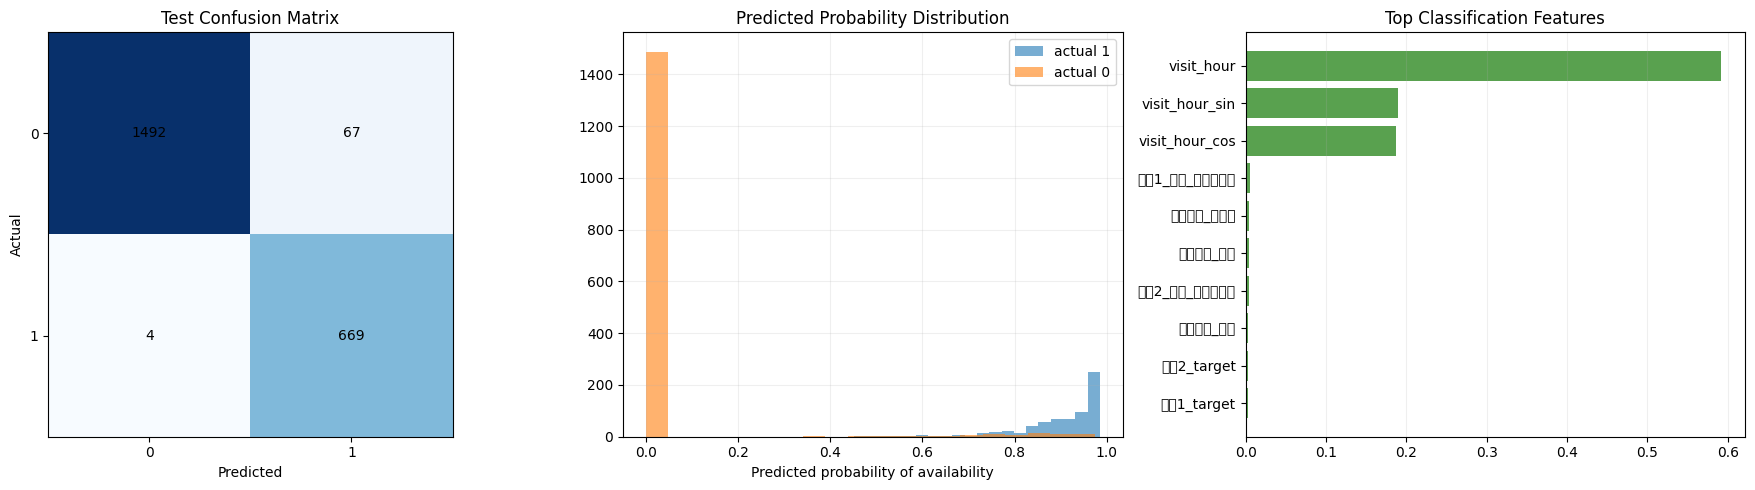

분류 모델 판단 기준:
- Accuracy가 높아도 불균형 데이터면 과신하면 안 된다.
- Precision이 높으면 탈 수 있다고 예측한 경우의 신뢰도가 높다.
- Recall이 높으면 실제로 탈 수 있는 경우를 잘 놓치지 않는다.
- ROC-AUC가 0.8 이상이면 구분력이 좋은 편이다.


In [55]:
cm = confusion_matrix(y_clf_test, clf_test_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Test Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="black")

axes[1].hist(clf_test_prob[y_clf_test == 1], bins=20, alpha=0.6, label="actual 1")
axes[1].hist(clf_test_prob[y_clf_test == 0], bins=20, alpha=0.6, label="actual 0")
axes[1].set_title("Predicted Probability Distribution")
axes[1].set_xlabel("Predicted probability of availability")
axes[1].legend()
axes[1].grid(alpha=0.2)

top_clf_importance = clf_importance_df.head(10).sort_values("importance")
axes[2].barh(top_clf_importance["feature"], top_clf_importance["importance"], color="#59a14f")
axes[2].set_title("Top Classification Features")
axes[2].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

print("분류 모델 판단 기준:")
print("- Accuracy가 높아도 불균형 데이터면 과신하면 안 된다.")
print("- Precision이 높으면 탈 수 있다고 예측한 경우의 신뢰도가 높다.")
print("- Recall이 높으면 실제로 탈 수 있는 경우를 잘 놓치지 않는다.")
print("- ROC-AUC가 0.8 이상이면 구분력이 좋은 편이다.")


# 최종 분석 정리

## 1. 분석 목적

이번 분석의 목적은 은평구 3개 스테이션(`ST-464`, `ST-481`, `ST-479`)을 대상으로 다음 두 가지를 예측하는 것이다.

1. 시즌이 시작되기 전에 각 스테이션에 자전거를 몇 대 채워야 하는가
2. 특정 시각에 해당 스테이션을 방문했을 때 자전거를 탈 수 있는가

여기서 시즌은 하루를 두 개의 운영 구간으로 나눈 것이다.

- 오전 시즌: `04:00 ~ 15:59`
- 오후 시즌: `16:00 ~ 다음날 03:59`

즉, 이 분석은 단순 이용량 예측이 아니라 `운영 관점의 수요 예측`과 `대여 가능 여부 예측`을 목표로 한다.

## 2. 사용 데이터

기본 데이터는 `정류장정보_시간대별_합친것.csv`이다.

주요 컬럼의 의미는 다음과 같다.

- `기준_날짜`: 집계 기준 날짜
- `집계_기준`: 해당 행이 출발시간 기준인지 도착시간 기준인지 나타내는 값
- `기준_시간대`: 집계된 시각
- `시작_대여소_ID`: 대여가 시작된 스테이션 ID
- `종료_대여소_ID`: 반납이 끝난 스테이션 ID
- `전체_건수`: 해당 조건에서의 이용 건수
- `전체_이용_분`: 전체 이용 시간 합계(분)
- `전체_이용_거리`: 전체 이용 거리 합계

날씨 데이터는 `Open-Meteo` 과거 날씨 API를 이용했다.

사용한 날씨 변수는 다음과 같다.

- `기온`: 시간 단위 기온
- `강수량`: 시간 단위 강수량
- `적설량`: 시간 단위 적설량
- `습도`: 시간 단위 상대습도

## 3. 데이터 전처리 과정

### 3-1. 대상 스테이션 필터링

전체 데이터에서 `시작_대여소_ID`가 아래 셋 중 하나인 행만 사용했다.

- `ST-464`
- `ST-481`
- `ST-479`

### 3-2. 날짜와 시간 변환

원본의 `기준_날짜`와 `기준_시간대`는 숫자처럼 저장되어 있었기 때문에 분석 가능한 날짜형으로 바꾸었다.

- `기준_날짜` -> `datetime` 날짜형
- `기준_시간대` -> `HHMM` 문자열 정리
- 날짜와 시간을 합쳐 `기준_일시` 생성

### 3-3. 집계 기준 통일

원본 데이터는 `출발시간`과 `도착시간`이 혼합되어 있었다.
분석 기준을 통일하기 위해 모든 행을 `출발시간` 기준으로 변환했다.

변환 방식은 다음과 같다.

- 원래 `출발시간`인 행은 그대로 사용
- 원래 `도착시간`인 행은 `전체_이용_분`을 이용해 출발 시각을 역산
- 즉 `출발_기준_일시 = 원본_기준_일시 - 전체_이용_분`

이 과정에서 자정을 넘는 경우 날짜가 하루 전으로 이동하는 것도 반영했다.

### 3-4. 결측성 데이터 제거

`전체_이용_거리 = 0` 이고 `전체_이용_분 = 0`인 행은 실제 이동 정보가 없는 결측성 데이터로 보고 제거했다.

### 3-5. 주말/공휴일 더미 생성

일자 특성을 반영하기 위해 다음 더미 변수를 만들었다.

- `주말_여부`: 주말이면 1, 아니면 0
- `공휴일_여부`: 공휴일이면 1, 아니면 0
- `주말_공휴일_여부`: 둘 중 하나라도 해당하면 1, 아니면 0

## 4. 시즌 정의와 시즌 테이블 생성

운영 기준에 맞추기 위해 하루를 두 개의 12시간 시즌으로 나누었다.

- 오전 시즌: `04:00 ~ 15:59`
- 오후 시즌: `16:00 ~ 다음날 03:59`

`00:00 ~ 03:59` 데이터는 같은 날 오전 시즌이 아니라 `전날 오후 시즌`에 속하도록 처리했다.

이후 개별 이용 기록 단위 데이터(`analysis_df`)를 아래 기준으로 집계한 `season_df`를 만들었다.

- `대여소_ID`
- `시즌_라벨`
- `시즌_시작일시`

집계된 주요 변수는 다음과 같다.

- `시즌_총이용건수`
- `시즌_총이용분`
- `시즌_총이용거리`
- `시즌_평균기온`
- `시즌_총강수량`
- `시즌_총적설량`
- `시즌_평균습도`

## 5. 첫 번째 예측 문제: 몇 대를 채워야 하는가

### 5-1. 왜 바로 실제 보충 대수를 쓸 수 없는가

현재 데이터에는 실제 재고, 실제 보충 기록, 실제 부족량이 없다.
따라서 완전한 정답 타깃을 바로 만들 수는 없다.

그래서 먼저 `proxy target`을 정의해서 회귀 문제를 만들었다.

### 5-2. 1차 타깃

처음에는 `시즌_총이용건수` 자체를 보충 필요 대수의 상한선으로 두었다.
하지만 이 값은 시즌 전체 수요이기 때문에 시즌 시작 시점 보충 수요와는 차이가 있을 수 있다.

### 5-3. 개선된 타깃

이후 더 운영적인 해석을 위해 `시즌 시작 후 초기 몇 시간의 수요`를 타깃으로 다시 정의했다.

비교한 타깃 윈도우는 다음 3개다.

- 시작 후 2시간 수요
- 시작 후 4시간 수요
- 시작 후 6시간 수요

이 방식은 시즌이 시작되자마자 얼마나 빨리 자전거가 빠져나가는지를 반영하므로, 시작 전 준비 대수의 프록시로 더 타당하다.

## 6. 회귀 모델링 과정

### 6-1. 시간 기준 데이터 분리

시계열 특성을 고려하여 데이터를 무작위로 섞지 않고 시간 순서대로 분리했다.

- 학습: 2024년 1월 ~ 9월
- 검증: 2024년 10월 ~ 11월
- 테스트: 2024년 12월

### 6-2. baseline 모델

먼저 다음 두 기준선을 만들었다.

- `mean baseline`: 학습 평균값으로 예측
- `lag baseline`: 직전 시즌 값을 그대로 예측

baseline은 이후 모델이 최소한 이 수준보다 좋아야 의미가 있다는 기준점 역할을 한다.

### 6-3. 선형회귀

다음으로 `numpy` 기반 선형회귀를 적용했다.
피처는 이전 시즌 수요, 날씨, 주말/공휴일, 시즌 코드, 월, 요일 등으로 구성했다.

이 모델은 해석이 쉽다는 장점이 있지만, 비선형 관계를 잘 잡지 못할 수 있다.

### 6-4. Random Forest

그 다음으로 `RandomForestRegressor`를 적용하여 더 복잡한 비선형 관계를 반영했다.

튜닝한 주요 파라미터는 다음과 같다.

- `n_estimators`
- `max_depth`
- `min_samples_leaf`

최적 조합은 검증셋 `R²`를 기준으로 선택했다.

## 7. R²의 의미와 판단 방법

`R²`는 모델이 타깃의 변동성을 얼마나 설명하는지를 나타내는 지표다.

일반적인 해석 기준은 다음과 같다.

- `0.8 이상`: 매우 좋음
- `0.7 이상`: 발표용으로 충분히 좋음
- `0.5 이상`: 설명력은 있으나 개선 여지 있음
- `0.3 미만`: 타깃이나 피처 재설계 필요 가능성 큼

단, `R²`는 혼자 보면 안 된다.
항상 아래 지표와 같이 해석해야 한다.

- `MAE`: 평균적으로 몇 대나 빗나가는가
- `RMSE`: 큰 오차에 더 민감한 지표
- 잔차 플롯: 특정 구간에서 오차가 몰리는지 확인

좋은 모델인지 판단할 때는 특히 아래를 같이 본다.

- `valid R²`와 `test R²` 차이가 작은가
- `R²`가 baseline보다 실제로 좋아졌는가
- MAE가 운영상 허용 가능한 수준인가
- 특정 스테이션/특정 시즌에서만 오차가 큰가

## 8. 두 번째 예측 문제: 방문 시 자전거를 탈 수 있는가

### 8-1. 왜 직접 라벨이 없는가

현재 데이터에는 실제 재고나 센서 기반 잔여 자전거 수가 없기 때문에, `방문 시 대여 가능 여부` 정답이 직접 존재하지 않는다.

따라서 이 문제는 운영 가정 기반의 분류 문제로 정의했다.

### 8-2. 분류 라벨 정의

분류 라벨은 다음 가정으로 만들었다.

- 시즌 시작 전에 `최적 타깃 윈도우` 기준으로 필요한 보충 대수를 준비한다.
- 방문 시각 전까지 누적 출발 수요가 준비 대수보다 작으면 `대여 가능 = 1`
- 누적 출발 수요가 준비 대수 이상이면 `대여 불가 = 0`

즉, 이 라벨은 실제 센서 재고가 아니라 `운영 시뮬레이션 기반 availability label`이다.

### 8-3. 분류 모델

`RandomForestClassifier`를 사용하여 방문 시각별 대여 가능 여부를 예측했다.
피처는 다음을 포함한다.

- 이전 시즌 수요
- 시작 시점 날씨
- 주말/공휴일 여부
- 시즌 라벨
- 방문 시각(`visit_hour`)
- 방문 시각의 주기형 표현(`sin`, `cos`)

### 8-4. 분류 모델 평가 지표

분류 문제는 다음 지표로 평가했다.

- `Accuracy`: 전체적으로 맞춘 비율
- `Precision`: 탈 수 있다고 예측한 경우 중 실제 가능한 비율
- `Recall`: 실제 가능한 경우를 얼마나 놓치지 않았는가
- `F1-score`: Precision과 Recall의 균형
- `ROC-AUC`: 확률적 구분력

특히 운영 관점에서는 `Recall`과 `ROC-AUC`를 함께 보는 것이 중요하다.

## 9. 시각화에서 확인한 핵심 포인트

노트북에서는 다음 시각화를 통해 모델과 데이터를 확인했다.

- 스테이션별 평균 시즌 이용건수
- 오전/오후 시즌별 수요 분포
- 기온과 시즌 수요 관계
- baseline 실제값 vs 예측값 그래프
- 선형회귀 실제값 vs 예측값, 잔차 분포
- Random Forest feature importance
- 타깃 윈도우별 `R²` 비교 그래프
- 분류 문제 confusion matrix
- 분류 모델 확률 분포 그래프

이 그래프들은 단순히 성능 숫자만 보는 것이 아니라, `왜 이 모델이 잘 되는지`, `어느 구간에서 틀리는지`, `어떤 변수가 중요한지`를 해석하기 위해 필요하다.

## 10. 이 분석의 한계

이번 분석에는 다음과 같은 한계가 있다.

1. 실제 재고 데이터가 없다.
- 따라서 보충 필요 대수와 대여 가능 여부는 모두 프록시 혹은 운영 가정 기반이다.

2. 실제 반납 유입량을 직접 모델링하지 않았다.
- 현재는 시작 스테이션 중심 분석이므로 유입/유출 재고 흐름 전체를 완벽히 반영하지 못한다.

3. 날씨는 평균 좌표 기준으로 붙였다.
- 세 스테이션 간 거리가 크지 않아서 큰 문제는 아닐 수 있지만, 더 정밀한 위치별 날씨는 아니다.

4. 운영 규칙은 가정 기반이다.
- 실제 운영팀의 보충 주기, 트럭 동선, 최소 안전 재고 정책과 다를 수 있다.

## 11. 다음 개선 방향

다음 단계에서는 아래 순서로 개선하는 것이 좋다.

1. 실제 운영에 더 가까운 타깃 재정의
- 실제 부족량 혹은 최소 필요 재고 기반 타깃 만들기

2. 추가 피처 생성
- 최근 3개 시즌 lag
- 최근 7일 같은 시즌 평균
- 강수 여부/적설 여부 더미
- 연휴 전후 더미

3. 더 강한 모델 비교
- `GradientBoostingRegressor`
- `XGBoostRegressor`
- `LightGBMRegressor`

4. 스테이션별 개별 모델 검토
- 스테이션마다 패턴이 다를 수 있으므로 개별 모델이 더 좋을 가능성이 있다.

## 12. 최종 해석

이번 노트북은 단순 이용량 집계가 아니라, `운영자가 시즌 시작 전에 몇 대를 배치해야 하는지`, `사용자가 특정 시각에 방문했을 때 대여가 가능한지`를 예측하기 위한 전체 머신러닝 파이프라인을 구성했다.

핵심은 다음과 같다.

- 데이터 전처리에서 출발시간 기준으로 통일했다.
- 날씨와 일정 정보까지 결합했다.
- 04시/16시 기준 운영 시즌으로 재구성했다.
- 회귀 문제와 분류 문제를 분리했다.
- baseline, 선형회귀, Random Forest를 비교했다.
- `R²`를 중심으로 모델 설명력을 판단하고, 동시에 MAE/RMSE/잔차도 함께 봤다.

따라서 이 노트북은 `데이터 정리 -> 시즌화 -> 타깃 정의 -> 회귀 모델 -> 분류 모델 -> 성능 해석`까지 이어지는 전체 분석 기록으로 사용할 수 있다.


## 결과 시각화 모음

아래 셀은 지금까지 나온 핵심 결과를 한 번에 시각화해서 보여준다.

포함되는 내용은 다음과 같다.

- 회귀 모델 성능 비교
- 타깃 윈도우별 성능 비교
- Random Forest 중요 피처 시각화
- 분류 모델 성능 비교
- 분류 중요 피처 시각화
- 스테이션별 시즌 수요 분포


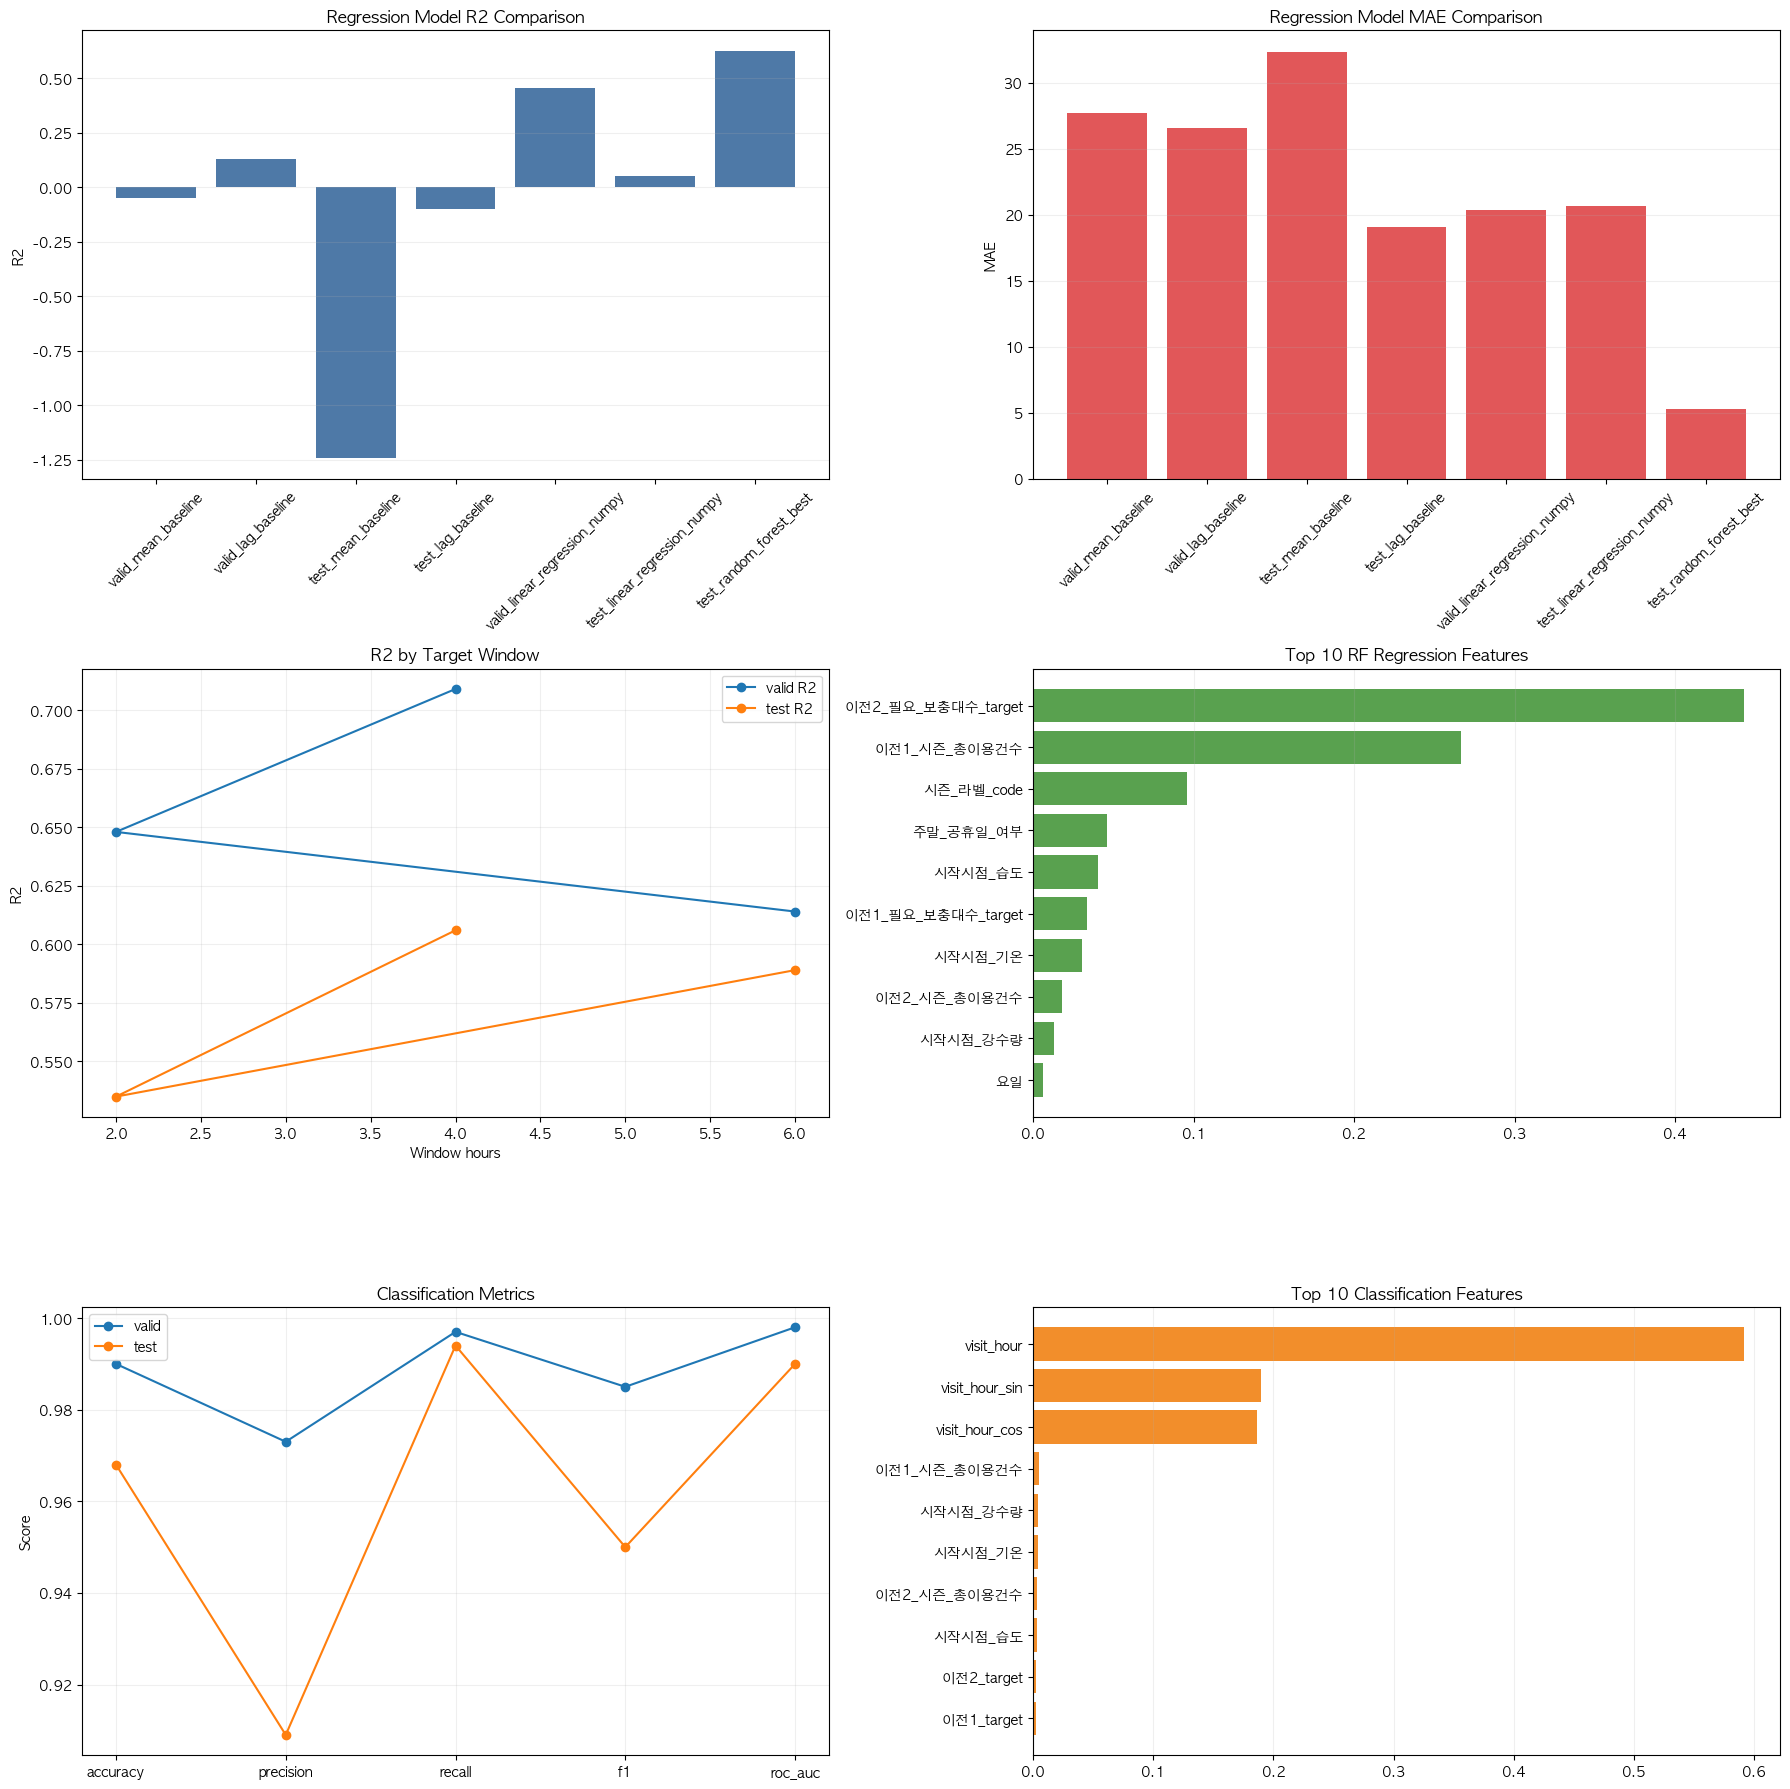

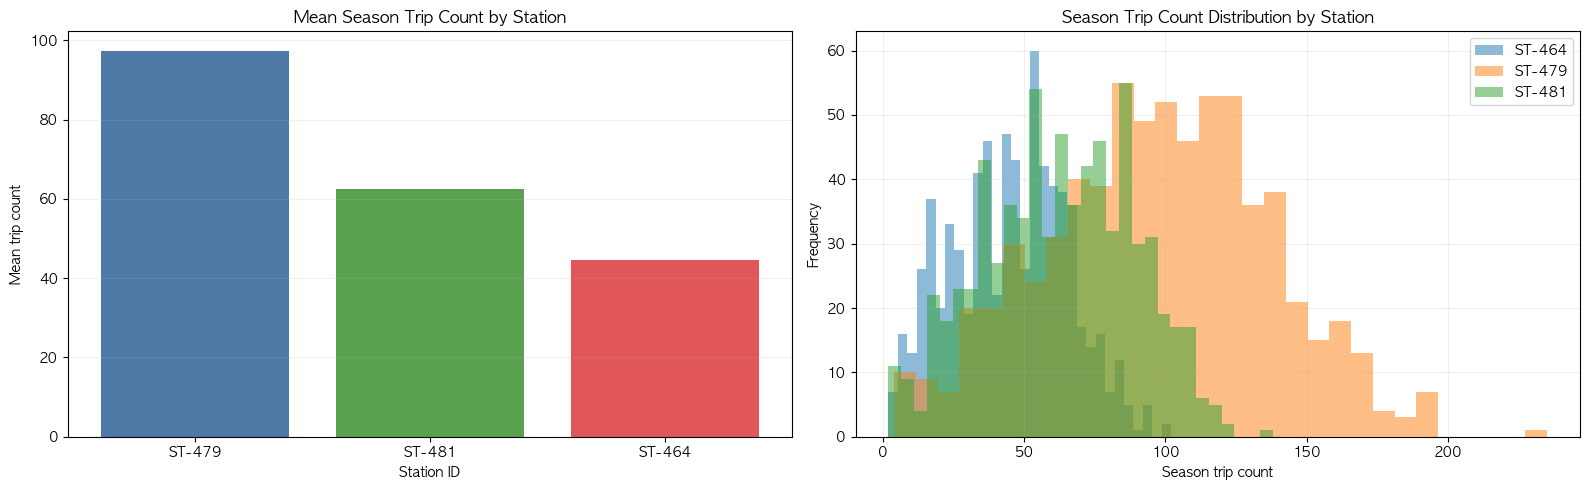

,split,model,mae,rmse,r2
0,valid,mean_baseline,27.744,36.703,-0.049
1,valid,lag_baseline,26.607,33.405,0.131
2,test,mean_baseline,32.351,35.972,-1.244
3,test,lag_baseline,19.091,25.203,-0.101
4,valid,linear_regression_numpy,20.328,26.457,0.455
5,test,linear_regression_numpy,20.666,23.369,0.053
6,test,random_forest_best,5.265,6.852,0.627


,window_hours,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
0,4,7.187,9.922,0.709,5.318,7.046,0.606
1,2,3.969,5.791,0.648,2.872,3.822,0.535
2,6,11.334,15.073,0.614,8.097,10.425,0.589


,split,accuracy,precision,recall,f1,roc_auc
0,valid,0.990,0.973,0.997,0.985,0.998
1,test,0.968,0.909,0.994,0.950,0.990


In [58]:
import matplotlib.pyplot as plt

regression_compare_df = pd.concat([
    baseline_result_df,
    linear_result_df,
    rf_result_df,
], ignore_index=True)

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# 1. 회귀 모델 R2 비교
reg_plot = regression_compare_df.copy()
reg_plot["label"] = reg_plot["split"] + "_" + reg_plot["model"]
axes[0, 0].bar(reg_plot["label"], reg_plot["r2"], color="#4e79a7")
axes[0, 0].set_title("Regression Model R2 Comparison")
axes[0, 0].set_ylabel("R2")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(axis="y", alpha=0.2)

# 2. 회귀 모델 MAE 비교
axes[0, 1].bar(reg_plot["label"], reg_plot["mae"], color="#e15759")
axes[0, 1].set_title("Regression Model MAE Comparison")
axes[0, 1].set_ylabel("MAE")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(axis="y", alpha=0.2)

# 3. 타깃 윈도우별 R2 비교
axes[1, 0].plot(window_result_df["window_hours"], window_result_df["valid_r2"], marker="o", label="valid R2")
axes[1, 0].plot(window_result_df["window_hours"], window_result_df["test_r2"], marker="o", label="test R2")
axes[1, 0].set_title("R2 by Target Window")
axes[1, 0].set_xlabel("Window hours")
axes[1, 0].set_ylabel("R2")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.2)

# 4. 회귀 중요 피처
top_rf_features = rf_feature_importance_df.head(10).sort_values("importance")
axes[1, 1].barh(top_rf_features["feature"], top_rf_features["importance"], color="#59a14f")
axes[1, 1].set_title("Top 10 RF Regression Features")
axes[1, 1].grid(axis="x", alpha=0.2)

# 5. 분류 모델 지표 비교
clf_plot_df = classification_result_df.melt(id_vars="split", var_name="metric", value_name="score")
for split in clf_plot_df["split"].unique():
    subset = clf_plot_df[clf_plot_df["split"] == split]
    axes[2, 0].plot(subset["metric"], subset["score"], marker="o", label=split)
axes[2, 0].set_title("Classification Metrics")
axes[2, 0].set_ylabel("Score")
axes[2, 0].legend()
axes[2, 0].grid(alpha=0.2)

# 6. 분류 중요 피처
top_clf_features = clf_importance_df.head(10).sort_values("importance")
axes[2, 1].barh(top_clf_features["feature"], top_clf_features["importance"], color="#f28e2b")
axes[2, 1].set_title("Top 10 Classification Features")
axes[2, 1].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

station_demand = season_df.groupby("대여소_ID")["시즌_총이용건수"].mean().sort_values(ascending=False)
axes[0].bar(station_demand.index, station_demand.values, color=["#4e79a7", "#59a14f", "#e15759"])
axes[0].set_title("Mean Season Trip Count by Station")
axes[0].set_xlabel("Station ID")
axes[0].set_ylabel("Mean trip count")
axes[0].grid(axis="y", alpha=0.2)

for station_id in sorted(season_df["대여소_ID"].unique()):
    subset = season_df[season_df["대여소_ID"] == station_id]
    axes[1].hist(subset["시즌_총이용건수"], bins=30, alpha=0.5, label=station_id)
axes[1].set_title("Season Trip Count Distribution by Station")
axes[1].set_xlabel("Season trip count")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

display(regression_compare_df)
display(window_result_df)
display(classification_result_df)


## 한글 폰트 설정

그래프에서 한글이 깨지는 경우 `matplotlib` 기본 폰트를 한글 지원 폰트로 바꿔야 한다.

이 셀을 먼저 실행한 뒤, 그래프를 그리는 셀들을 다시 실행하면 한글이 정상적으로 보인다.


적용된 폰트: AppleGothic


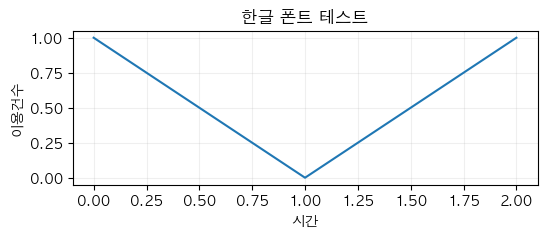

In [57]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

font_candidates = [
    "AppleGothic",
    "NanumGothic",
    "Malgun Gothic",
    "Noto Sans CJK KR",
    "Arial Unicode MS",
]

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = None

for font_name in font_candidates:
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font is None:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 시스템 폰트를 확인하세요.")
else:
    rcParams["font.family"] = selected_font
    rcParams["axes.unicode_minus"] = False
    print(f"적용된 폰트: {selected_font}")

plt.figure(figsize=(6, 2))
plt.title("한글 폰트 테스트")
plt.plot([0, 1, 2], [1, 0, 1])
plt.xlabel("시간")
plt.ylabel("이용건수")
plt.grid(alpha=0.2)
plt.show()
